In [826]:
import pandas as pd
import sqlalchemy
import psycopg2

# --- Database Connection Details ---
# Make sure your Docker container is running!
DB_NAME = "chris_db"
DB_USER = "postgres"
DB_PASSWORD = "password"  # The password you set in your docker run command
DB_HOST = "localhost"
DB_PORT = "5432"

# Create the database connection URL
db_url = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Create a SQLAlchemy engine
try:
    engine = sqlalchemy.create_engine(db_url)
    print("Successfully connected to the database!")
except Exception as e:
    print(f"Failed to connect to the database. Error: {e}")


# --- Read Data from the 'binance_trades' Table ---
table_name_trades = "binance_trades"
# Corrected Query: Using 'timestamp_ms' instead of 'time'
query_trades = f"SELECT * FROM {table_name_trades} ORDER BY timestamp_ms DESC LIMIT 1000;"

try:
    with engine.connect() as connection:
        df_trades = pd.read_sql(query_trades, connection)
    
    print(f"\nSuccessfully loaded {len(df_trades)} rows from '{table_name_trades}'.")
    # In a script, you'd use print(). In a notebook, display() is prettier.
    # display(df_trades.head()) 
    print(df_trades.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name_trades}'. Error: {e}")


# --- Read Data from the 'binance_orderbook_features' Table ---
table_name_ob = "binance_orderbook_features"
# Corrected Query: Using 'timestamp_ms' instead of 'time'
query_ob = f"SELECT * FROM {table_name_ob} ORDER BY timestamp_ms DESC LIMIT 1000;"

try:
    with engine.connect() as connection:
        df_orderbook = pd.read_sql(query_ob, connection)
    
    print(f"\nSuccessfully loaded {len(df_orderbook)} rows from '{table_name_ob}'.")
    # In a script, you'd use print(). In a notebook, display() is prettier.
    # display(df_orderbook.head())
    print(df_orderbook.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name_ob}'. Error: {e}")


Successfully connected to the database!

Successfully loaded 1000 rows from 'binance_trades'.
    timestamp_ms  sell_volume  buy_volume  vwap_sell_price  vwap_buy_price  \
0  1750525384313         0.00       0.000              0.0        0.000000   
1  1750525384120         0.01       0.000         103484.7        0.000000   
2  1750525384103         0.00       0.000              0.0        0.000000   
3  1750525383905         0.00       0.027              0.0   103481.211111   
4  1750525383813         0.00       0.038              0.0   103478.715789   

   total_volume  total_trade_count  
0         0.000                  0  
1         0.010                  1  
2         0.000                  0  
3         0.027                 14  
4         0.038                  4  

Successfully loaded 1000 rows from 'binance_orderbook_features'.
    timestamp_ms  bid_l1_price  bid_l1_cumulative_qty  bid_l1_weighted_price  \
0  1750525384797      103484.7                 16.371               1

# binance trades

In [827]:
limit = 700000

In [828]:
# --- Read Data from the 'binance_trades' Table ---
table_name = "binance_trades"
query = f"SELECT * FROM {table_name} ORDER BY timestamp_ms DESC LIMIT {limit};"

try:
    with engine.connect() as connection:
        df_binance_trades = pd.read_sql(query, connection)
    
    print(f"Successfully loaded {len(df_binance_trades)} rows from '{table_name}'.")
    display(df_binance_trades.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name}'. Error: {e}")

Successfully loaded 700000 rows from 'binance_trades'.


,timestamp_ms,sell_volume,buy_volume,vwap_sell_price,vwap_buy_price,total_volume,total_trade_count
0,1750525406110,0.000,0.0,0.0,0.0,0.000,0
1,1750525405948,0.001,0.0,103492.2,0.0,0.001,1
2,1750525405859,0.000,0.0,0.0,0.0,0.000,0
3,1750525405751,0.000,0.0,0.0,0.0,0.000,0
4,1750525405638,0.000,0.0,0.0,0.0,0.000,0


# binance orderbook

In [829]:
# --- Read Data from the 'binance_orderbook_features' Table ---
table_name = "binance_orderbook_features"
query = f"SELECT * FROM {table_name} ORDER BY timestamp_ms DESC LIMIT {limit};"

try:
    with engine.connect() as connection:
        df_binance_ob = pd.read_sql(query, connection)
    
    print(f"Successfully loaded {len(df_binance_ob)} rows from '{table_name}'.")
    display(df_binance_ob.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name}'. Error: {e}")

Successfully loaded 700000 rows from 'binance_orderbook_features'.


,timestamp_ms,bid_l1_price,bid_l1_cumulative_qty,bid_l1_weighted_price,ask_l1_price,ask_l1_cumulative_qty,ask_l1_weighted_price,bid_l5_price,bid_l5_cumulative_qty,bid_l5_weighted_price,...,bid_l10_weighted_price,ask_l10_price,ask_l10_cumulative_qty,ask_l10_weighted_price,bid_l20_price,bid_l20_cumulative_qty,bid_l20_weighted_price,ask_l20_price,ask_l20_cumulative_qty,ask_l20_weighted_price
0,1750525413393,103492.2,21.272,103492.2,103492.3,2.337,103492.3,103491.7,21.534,103492.197367,...,103492.172329,103493.5,2.620,103492.355076,103489.3,23.160,103492.045069,103495.6,3.531,103493.135429
1,1750525413228,103492.2,21.272,103492.2,103492.3,2.151,103492.3,103491.7,21.534,103492.197367,...,103492.172329,103493.5,2.434,103492.359285,103489.3,23.160,103492.045069,103495.6,3.345,103493.181883
2,1750525413085,103492.2,21.260,103492.2,103492.3,2.147,103492.3,103491.7,21.522,103492.197365,...,103492.172314,103493.5,2.366,103492.328529,103489.3,23.148,103492.044989,103495.6,3.277,103493.176747
3,1750525412823,103492.2,21.259,103492.2,103492.3,2.147,103492.3,103491.7,21.521,103492.197365,...,103492.172313,103493.5,2.366,103492.328529,103489.3,23.147,103492.044982,103495.4,3.492,103493.274485
4,1750525412624,103492.2,21.279,103492.2,103492.3,2.147,103492.3,103491.7,21.541,103492.197368,...,103492.172338,103493.5,2.366,103492.328529,103489.3,23.167,103492.045116,103495.4,3.349,103493.187996


# brti data

In [830]:
# --- Read Data from the 'brti_prices' Table ---
table_name = "brti_prices"
query = f"SELECT * FROM {table_name} ORDER BY timestamp_ms DESC LIMIT {limit};"

try:
    with engine.connect() as connection:
        df_brti = pd.read_sql(query, connection)
    
    print(f"Successfully loaded {len(df_brti)} rows from '{table_name}'.")
    display(df_brti.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name}'. Error: {e}")

Successfully loaded 65460 rows from 'brti_prices'.


,timestamp_ms,brti_price,simple_average
0,1750525399442,103559.96,103555.563333
1,1750525398398,103562.24,103555.552833
2,1750525397235,103563.21,103555.524667
3,1750525396394,103562.31,103555.449000
4,1750525395379,103563.00,103555.388500


# kalshi trades

In [831]:
# --- Read Data from the 'kalshi_trades' Table ---
table_name = "kalshi_trades"
query = f"SELECT * FROM {table_name} ORDER BY timestamp_ms DESC LIMIT {limit};"

try:
    with engine.connect() as connection:
        df_kalshi_trades = pd.read_sql(query, connection)
    
    print(f"Successfully loaded {len(df_kalshi_trades)} rows from '{table_name}'.")
    display(df_kalshi_trades.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name}'. Error: {e}")

Successfully loaded 4737 rows from 'kalshi_trades'.


,timestamp_ms,ticker,yes_price,count,taker_side,trade_value
0,1750487884819,KXBTCD-25JUN2117-T103499.99,57,10,yes,570
1,1750487529318,KXBTCD-25JUN2117-T102999.99,73,100,yes,7300
2,1750487529237,KXBTCD-25JUN2117-T102999.99,73,300,no,21900
3,1750487160478,KXBTCD-25JUN2117-T103499.99,55,10,yes,550
4,1750486715816,KXBTCD-25JUN2117-T102999.99,77,350,yes,26950


# kalshi orderbook

In [832]:
# --- Read Data from the 'kalshi_orderbooks' Table ---
table_name = "kalshi_orderbooks"
query = f"SELECT * FROM {table_name} ORDER BY timestamp_ms DESC LIMIT {limit};"

try:
    with engine.connect() as connection:
        df_kalshi_ob = pd.read_sql(query, connection)
    
    print(f"Successfully loaded {len(df_kalshi_ob)} rows from '{table_name}'.")
    display(df_kalshi_ob.head())
except Exception as e:
    print(f"Failed to read data from table '{table_name}'. Error: {e}")

Successfully loaded 464574 rows from 'kalshi_orderbooks'.


,timestamp_ms,ticker,best_bid,best_bid_qty,best_ask,best_ask_qty
0,1750525275811,KXBTCD-25JUN2117-T103499.99,55,10,61,500
1,1750525275760,KXBTCD-25JUN2117-T103499.99,55,10,64,300
2,1750525273960,KXBTCD-25JUN2117-T104499.99,0,0,15,500
3,1750525273905,KXBTCD-25JUN2117-T104499.99,1,50,15,500
4,1750525271641,KXBTCD-25JUN2117-T113499.99,0,0,46,960


# filter for large trades

In [833]:
import numpy as np
import matplotlib.pyplot as plt

In [834]:
threshold = 100
large_buy_trades = df_binance_trades[df_binance_trades['buy_volume'] > threshold]
large_sell_trades = df_binance_trades[df_binance_trades['sell_volume'] > threshold]

In [ ]:
large_buy_trades

In [ ]:
large_sell_trades

In [837]:
len(df_kalshi_ob)

464574

In [838]:
df_kalshi_ob.head()

,timestamp_ms,ticker,best_bid,best_bid_qty,best_ask,best_ask_qty
0,1750525275811,KXBTCD-25JUN2117-T103499.99,55,10,61,500
1,1750525275760,KXBTCD-25JUN2117-T103499.99,55,10,64,300
2,1750525273960,KXBTCD-25JUN2117-T104499.99,0,0,15,500
3,1750525273905,KXBTCD-25JUN2117-T104499.99,1,50,15,500
4,1750525271641,KXBTCD-25JUN2117-T113499.99,0,0,46,960


In [839]:
import pytz
import re
from datetime import datetime

def get_strike(ticker):
    return float(ticker.split('-')[2][1:])

def get_expiration(ticker_str): 
    """
    Parses a Kalshi ticker string to get the expiration timestamp in milliseconds.
    The expected format is YYMMMDDHH (e.g., '25JUN2117').
    """
    # Example ticker: "INX-25JUN2117"
    # This means Year=25 (2025), Month=JUN, Day=21, Hour=17
    ticker_str = ticker_str.split('-')[1]

    # The format is YYMMMDDHH
    pattern = r'(\d{2})([A-Z]{3})(\d{2})(\d{2})'
    match = re.match(pattern, ticker_str)
    
    if not match:
        raise ValueError(f"Invalid ticker format: {ticker_str}. Expected format: YYMMMDDHH")
        
    # Correctly assign the parsed groups based on YYMMMDDHH format
    year_str, month_str, day_str, hour_str = match.groups()
    
    # Convert to integers
    year = 2000 + int(year_str)  # '25' -> 2025
    day = int(day_str)           # '21' -> 21
    hour = int(hour_str)         # '17' -> 17
    
    # Month mapping
    month_map = {
        'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
        'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
    }
    if month_str not in month_map:
        raise ValueError(f"Invalid month abbreviation: {month_str}")
        
    month = month_map[month_str]
    
    # Create timezone-aware datetime object robustly
    est_tz = pytz.timezone('US/Eastern')
    naive_dt = datetime(year, month, day, hour, 0, 0)
    expiry_dt = est_tz.localize(naive_dt)

    # Convert to milliseconds timestamp
    timestamp_ms = int(expiry_dt.timestamp() * 1000)
    return timestamp_ms

In [ ]:
# make a large plot with subplots

num_trades = len(large_sell_trades)
# rows = int(np.ceil(np.sqrt(num_trades)))
# cols = int(np.ceil(num_trades / rows))

time_threshold_seconds = 5
kalshi_time_threshold_seconds = 10
kalshi_strike_threshold = 500

# fig, axs = plt.subplots(rows, cols, figsize=(10, 10))

for i, trade in enumerate(large_sell_trades.iterrows()):

    # row = i // cols
    # col = i % cols

    # ax = axs[row, col]
    plt.figure(figsize=(5, 5))
    ax = plt.gca()

    timestamp = trade[1]['timestamp_ms']
    nearby_brti_price = df_brti[abs(df_brti['timestamp_ms'] - timestamp) < time_threshold_seconds*1000]

    ax.plot(nearby_brti_price['timestamp_ms'], nearby_brti_price['brti_price'])
    ax.axvline(x=timestamp, color='red', linestyle='--')
    # check for nearby kalshi trades
    nearby_kalshi_trades = df_kalshi_trades[abs(df_kalshi_trades['timestamp_ms'] - timestamp) < kalshi_time_threshold_seconds*1000]
    total_value = 0
    for kalshi_trade in nearby_kalshi_trades.iterrows():
        # check if trade was buy or sell
        if kalshi_trade[1]['taker_side'] == 'yes':
            color = 'purple'
        else:
            color = 'orange'
        total_value += kalshi_trade[1]['trade_value']/100
        ax.axvline(x=kalshi_trade[1]['timestamp_ms'], color=color, linestyle='--')

    # put trade information on title
    ax.set_title(f"Trade {i+1}: Sell Volume: {trade[1]['sell_volume']:.1f} | Total Value: ${total_value:.2f}")
    plt.tight_layout()
    plt.show()

    # lets plot the orderbooks for contracts near the money
    avg_price = nearby_brti_price['brti_price'].mean()
    nearby_orderbooks = df_kalshi_ob[abs(df_kalshi_ob['timestamp_ms'] - timestamp) < time_threshold_seconds*1000]

    binance_market_nearby = df_binance_ob[abs(df_binance_ob['timestamp_ms'] - timestamp) < time_threshold_seconds*1000]
    mid_market_price = (binance_market_nearby['bid_l1_price'] + binance_market_nearby['ask_l1_price'])/2

    for ticker in nearby_orderbooks['ticker'].unique():
        # plot the bid and ask prices

        ticker_df = df_kalshi_ob[df_kalshi_ob['ticker'] == ticker]

        strike = get_strike(ticker)
        if abs(strike - avg_price) > kalshi_strike_threshold:
            continue

        plt.figure(figsize=(5, 5))
        ax = plt.gca()
        nearby_orderbook = nearby_orderbooks[nearby_orderbooks['ticker'] == ticker]
        ax.plot(nearby_orderbook['timestamp_ms'], nearby_orderbook['best_bid'], color='blue', linestyle='--')
        ax.plot(nearby_orderbook['timestamp_ms'], nearby_orderbook['best_ask'], color='green', linestyle='--')

        ax.set_title(f"Strike: {strike} | Avg Price: {avg_price:.2f}")   
        ax.axvline(x=timestamp, color='red', linestyle='--')

        plt.twinx()
        ax2 = plt.gca()
        # ax2.plot(binance_market_nearby['timestamp_ms'], mid_market_price, color='red', linestyle='--')

        plt.tight_layout()
        plt.show()



# do the same for large buy trades
num_trades = len(large_buy_trades)
# rows = int(np.ceil(np.sqrt(num_trades)))
# cols = int(np.ceil(num_trades / rows))

# fig, axs = plt.subplots(rows, cols, figsize=(10, 10))

for i, trade in enumerate(large_buy_trades.iterrows()):

    #row = i // cols
    #col = i % cols

    # ax = axs[row, col]
    plt.figure(figsize=(5, 5))
    ax = plt.gca()

    # find nearby brti prices
    timestamp = trade[1]['timestamp_ms']
    nearby_brti_price = df_brti[abs(df_brti['timestamp_ms'] - timestamp) < time_threshold_seconds*1000]
    ax.plot(nearby_brti_price['timestamp_ms'], nearby_brti_price['brti_price'])
    ax.axvline(x=timestamp, color='green', linestyle='--')

    total_value = 0

    # check for nearby kalshi trades
    avg_price = nearby_brti_price['brti_price'].mean()
    nearby_kalshi_trades = df_kalshi_trades[abs(df_kalshi_trades['timestamp_ms'] - timestamp) < kalshi_time_threshold_seconds*1000]
    for kalshi_trade in nearby_kalshi_trades.iterrows():
        # check if trade was buy or sell
        if kalshi_trade[1]['taker_side'] == 'yes':
            color = 'purple'
        else:
            color = 'orange'

        total_value += kalshi_trade[1]['trade_value']/100
        ax.axvline(x=kalshi_trade[1]['timestamp_ms'], color=color, linestyle='--')

    # put trade information on title
    ax.set_title(f"Trade {i+1}: Buy Volume: {trade[1]['buy_volume']:.1f} | Total Value: ${total_value:.2f}")
    plt.tight_layout()
    plt.show()
    # lets plot the orderbooks for contracts near the money
    nearby_orderbooks = df_kalshi_ob[abs(df_kalshi_ob['timestamp_ms'] - timestamp) < time_threshold_seconds*1000]

    binance_market_nearby = df_binance_ob[abs(df_binance_ob['timestamp_ms'] - timestamp) < time_threshold_seconds*1000]
    mid_market_price = (binance_market_nearby['bid_l1_price'] + binance_market_nearby['ask_l1_price'])/2

    for ticker in nearby_orderbooks['ticker'].unique():
        # plot the bid and ask prices

        ticker_df = df_kalshi_ob[df_kalshi_ob['ticker'] == ticker]

        strike = get_strike(ticker)
        if abs(strike - avg_price) > kalshi_strike_threshold:
            continue

        plt.figure(figsize=(5, 5))
        ax = plt.gca()
        print('making plot!')
        nearby_orderbook = nearby_orderbooks[nearby_orderbooks['ticker'] == ticker]
        ax.plot(nearby_orderbook['timestamp_ms'], nearby_orderbook['best_bid'], color='blue', linestyle='--')
        ax.plot(nearby_orderbook['timestamp_ms'], nearby_orderbook['best_ask'], color='green', linestyle='--')
        ax.axvline(x=timestamp, color='red', linestyle='--')
        ax.set_title(f"Strike: {strike} | Avg Price: {avg_price:.2f}")   
        plt.twinx()
        ax2 = plt.gca()
        # ax2.plot(binance_market_nearby['timestamp_ms'], mid_market_price, color='red', linestyle='--')

        plt.tight_layout()
        plt.show()



# trying to price btc binaries

In [440]:
window = 3600
log_returns = np.log(df_brti['brti_price'] / df_brti['brti_price'].shift(1))
rolling_std = log_returns.rolling(window=window).std()

# annualize the volatility
seconds_per_year = 365 * 24 * 60 * 60
annualized_volatility = rolling_std * np.sqrt(seconds_per_year)
df_brti['realized_volatility'] = annualized_volatility

df_brti.tail()

,timestamp_ms,brti_price,simple_average,realized_volatility
51595,1750434080104,104402.27,104399.044000,0.337352
51596,1750434078851,104403.68,104398.237500,0.337352
51597,1750434077934,104400.28,104396.423333,0.337367
51598,1750434077013,104406.89,104394.495000,0.337416
51599,1750434076708,104382.10,104382.100000,0.338128


In [441]:
grouped_dfs = {}
for name, group in df_kalshi_ob.groupby('ticker'):
    grouped_dfs[name] = group

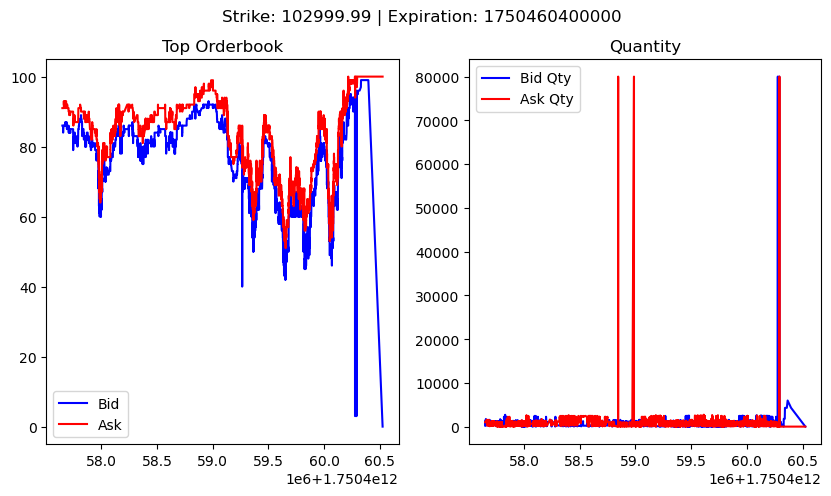

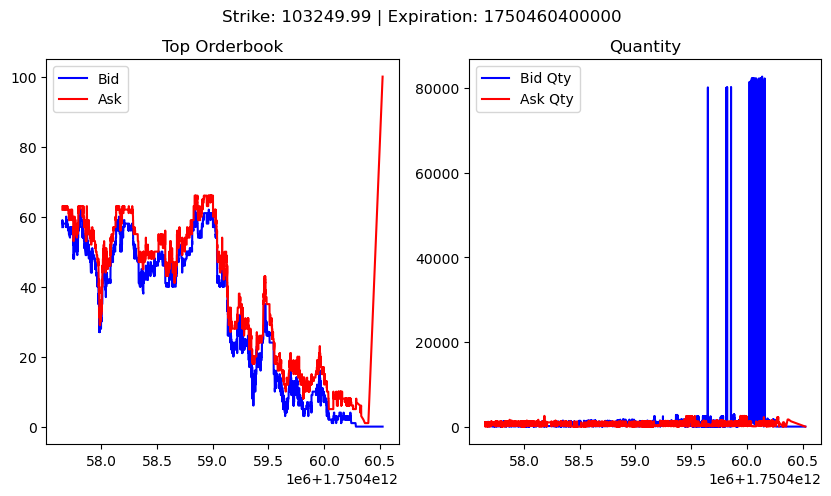

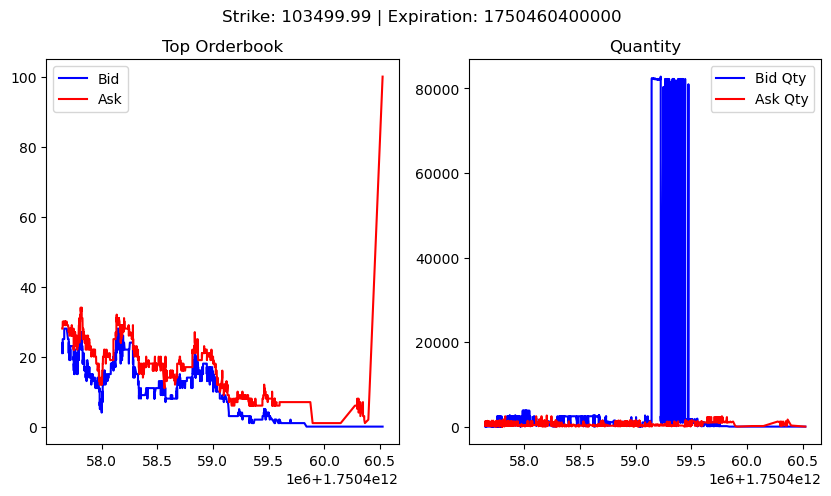

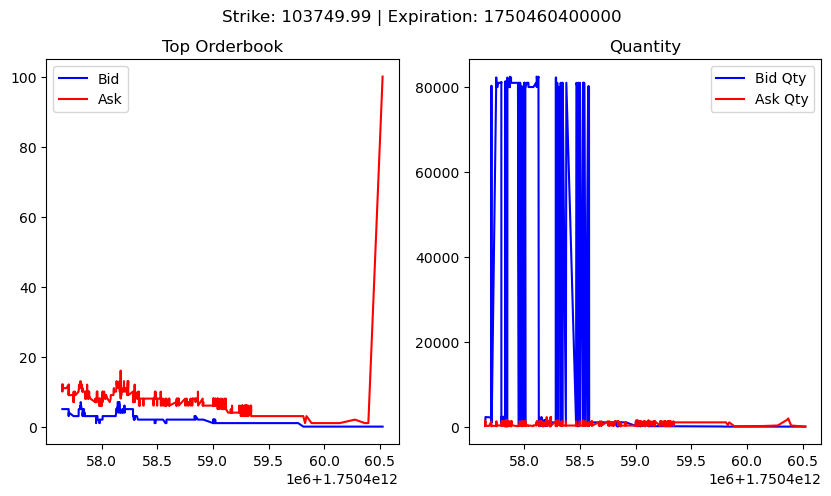

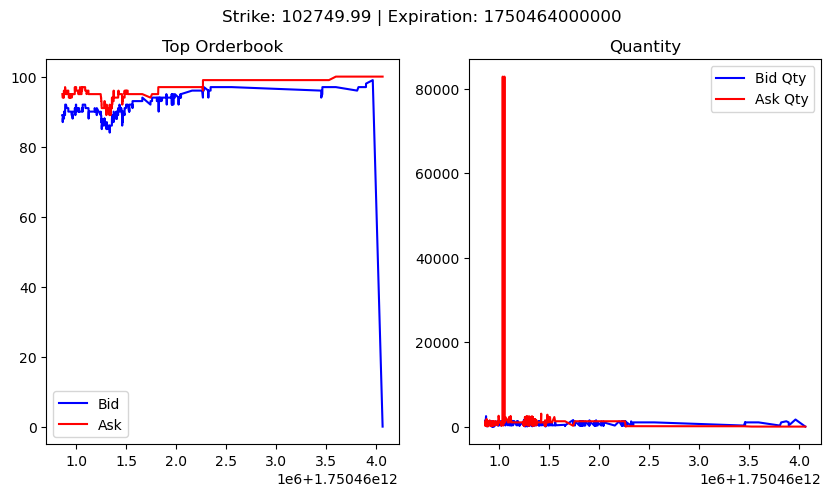

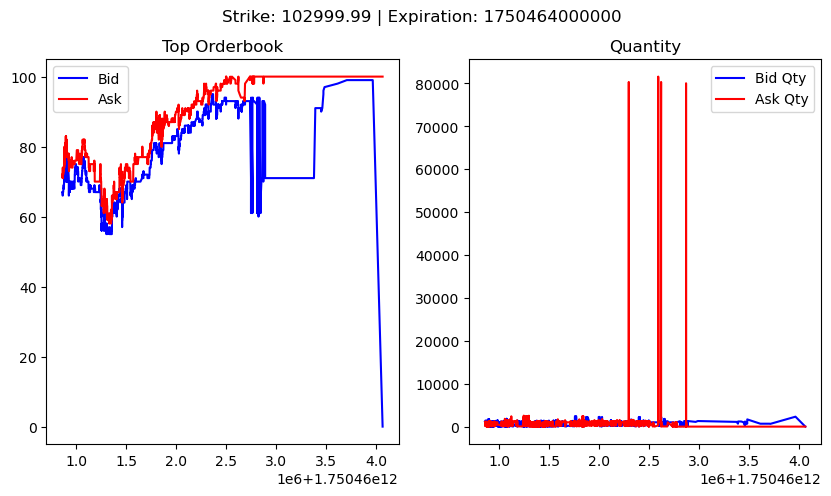

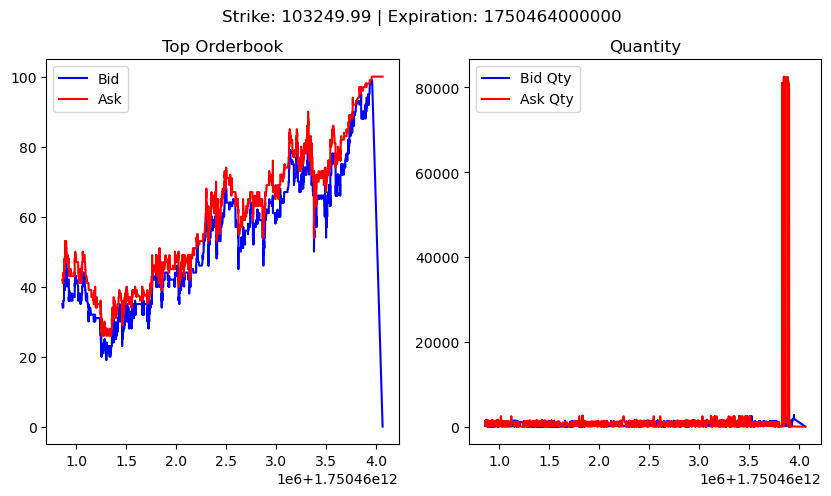

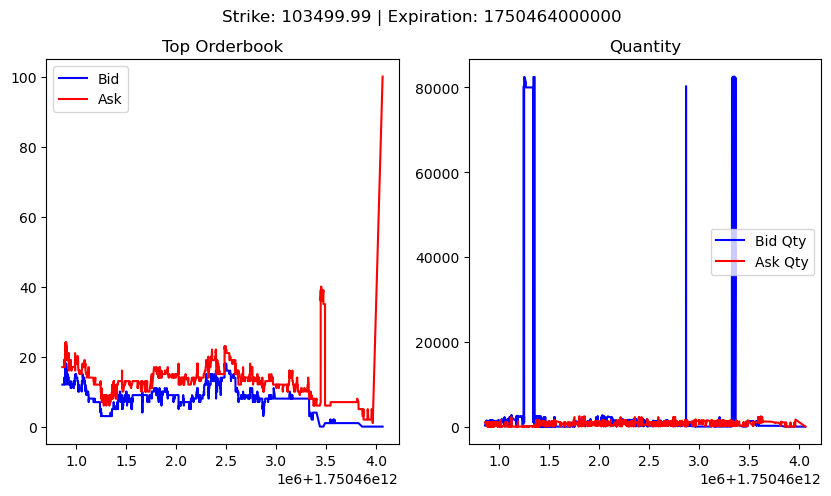

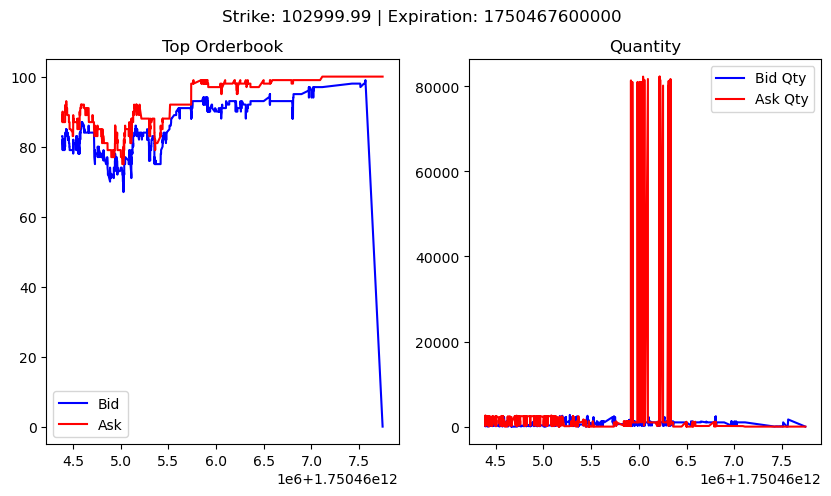

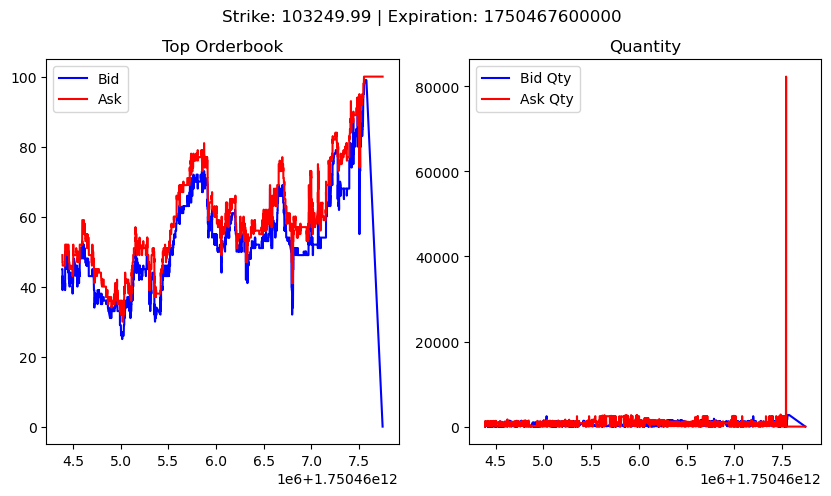

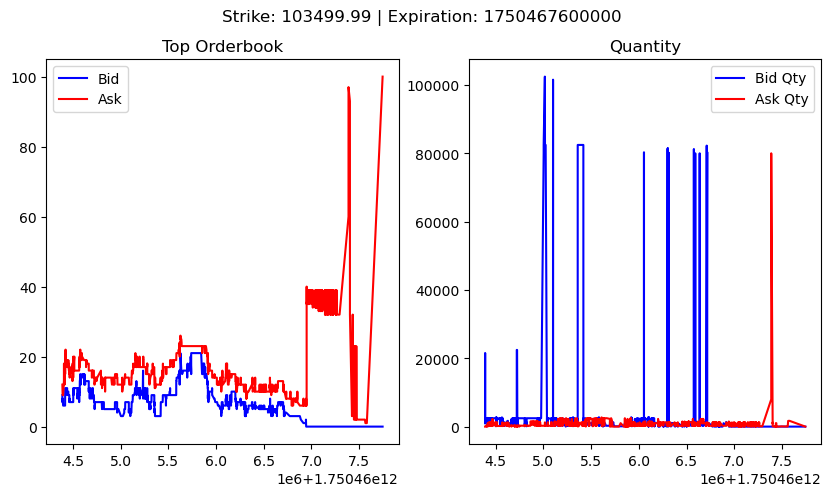

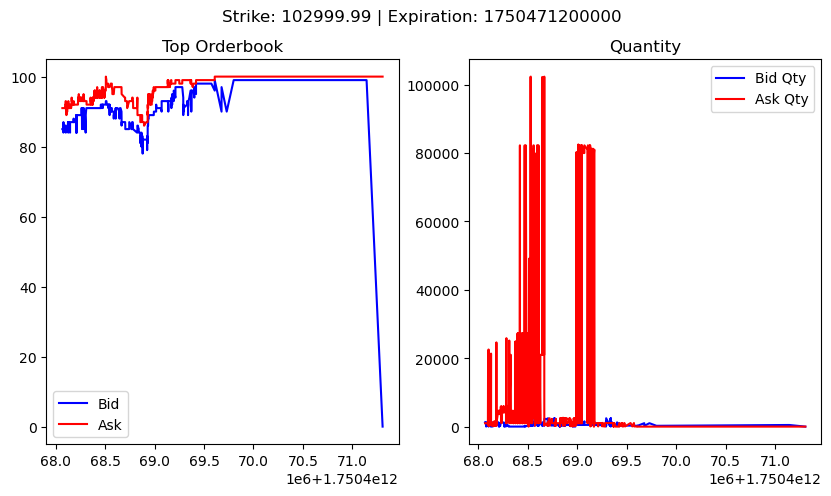

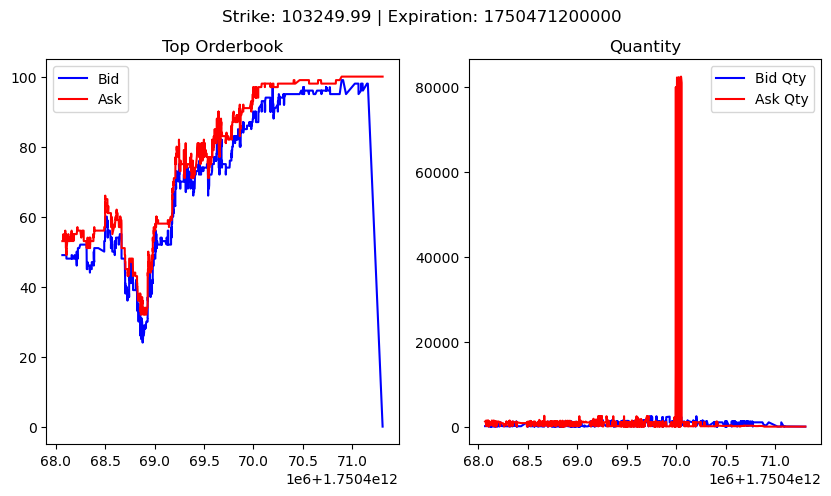

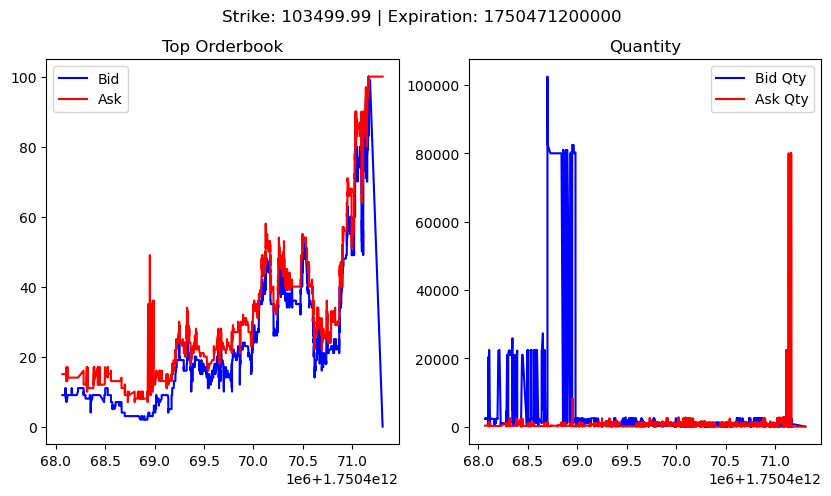

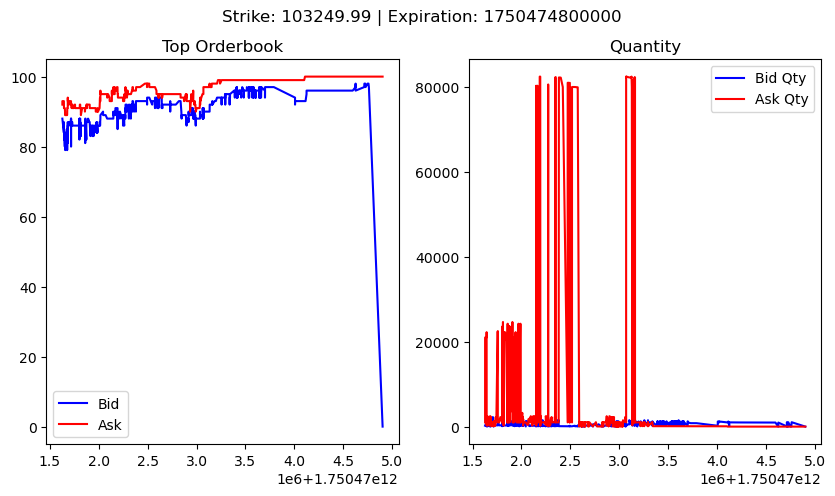

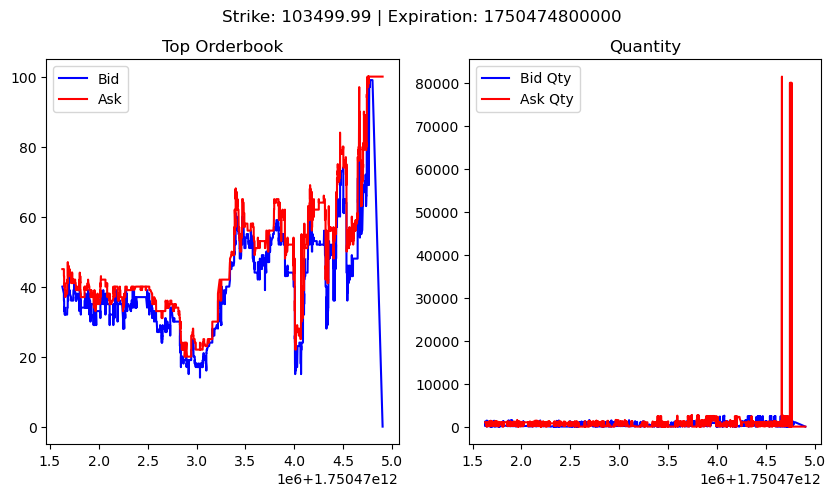

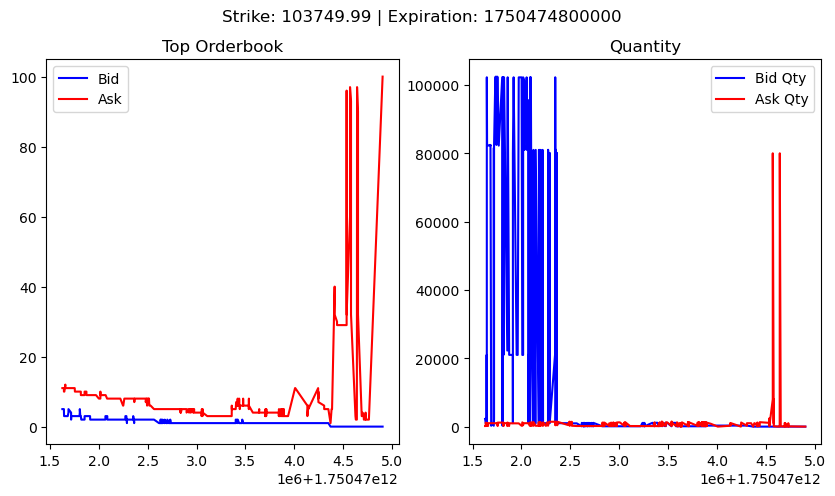

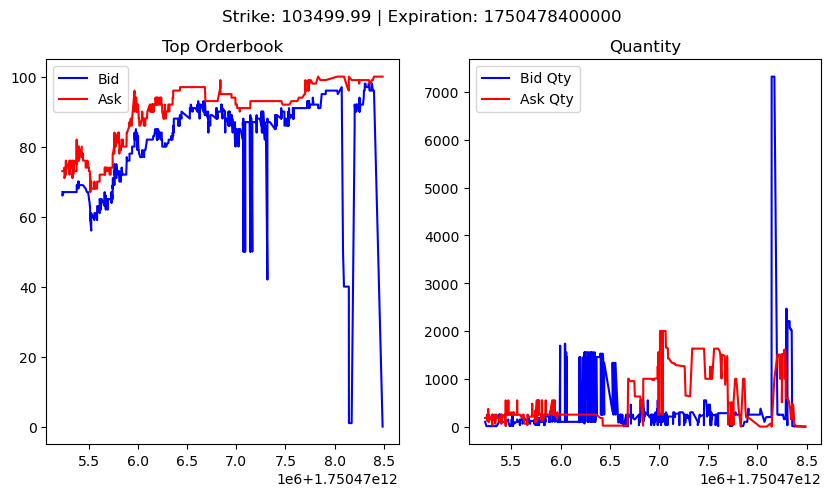

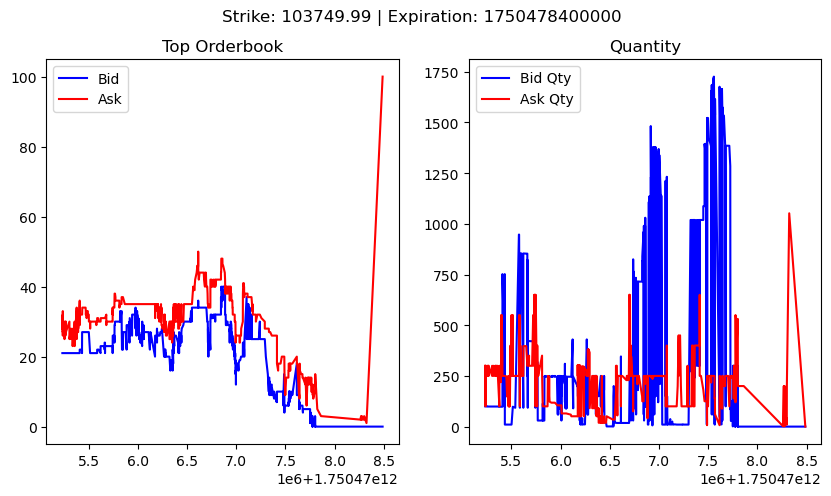

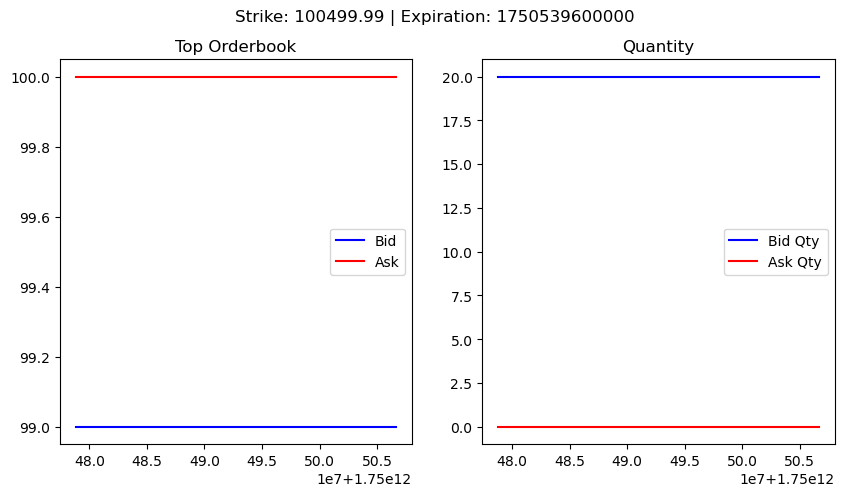

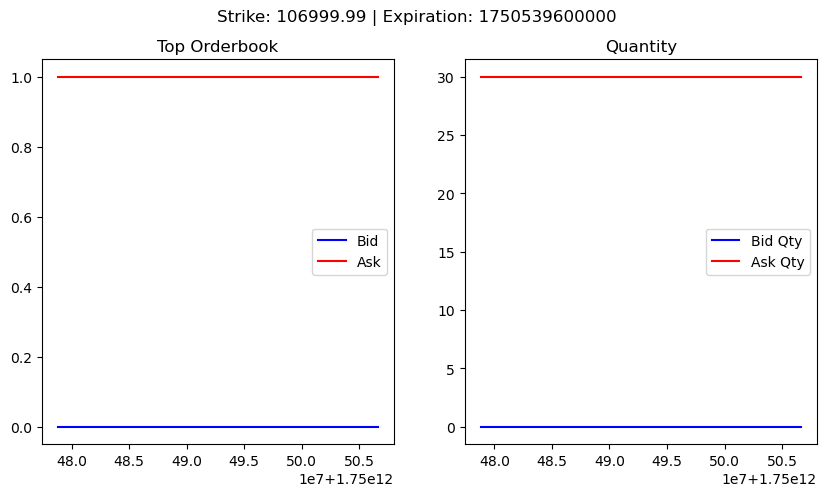

In [442]:
for key in grouped_dfs.keys():
    group_df = grouped_dfs[key]
    # get the strike price
    strike = get_strike(key)
    expiration = get_expiration(key)

    bids = group_df['best_bid']
    asks = group_df['best_ask']
    best_bid_qty = group_df['best_bid_qty']
    best_ask_qty = group_df['best_ask_qty']
    timestamp = group_df['timestamp_ms']

    # get average bid ask spread
    avg_bid_ask_spread = (asks - bids).mean()
    avg_spread_threshold = 12
    if avg_bid_ask_spread > avg_spread_threshold:
        continue

    plt.figure(figsize=(10, 5))
    plt.suptitle(f"Strike: {strike} | Expiration: {expiration}")
    plt.subplot(1, 2, 1)
    ax = plt.gca()
    ax.set_title("Top Orderbook")
    ax.plot(timestamp, bids, color='blue', label='Bid')
    ax.plot(timestamp, asks, color='red', label='Ask')
    ax.legend()

    plt.subplot(1, 2, 2)
    ax = plt.gca()
    ax.set_title("Quantity")
    ax.plot(timestamp, best_bid_qty, color='blue', label='Bid Qty')
    ax.plot(timestamp, best_ask_qty, color='red', label='Ask Qty')
    ax.legend()

    plt.show()




# volatility smile for the binaries

In [444]:
df_brti.tail()

,timestamp_ms,brti_price,simple_average,realized_volatility
51595,1750434080104,104402.27,104399.044000,0.337352
51596,1750434078851,104403.68,104398.237500,0.337352
51597,1750434077934,104400.28,104396.423333,0.337367
51598,1750434077013,104406.89,104394.495000,0.337416
51599,1750434076708,104382.10,104382.100000,0.338128


In [445]:
from tqdm import tqdm

def add_brti_price(timestamp, threshold=2):
    # threshold is in seconds
    threshold_ms = threshold * 1000

    # Step 1: Filter the DataFrame to a small window around the timestamp.
    candidate_rows = df_brti[abs(df_brti['timestamp_ms'] - timestamp) < threshold_ms]

    # Step 2: If no data is within the window, there's no match.
    if candidate_rows.empty:
        return None
    
    # Step 3: Find the index of the row with the minimum absolute time difference.
    closest_row_index = (candidate_rows['timestamp_ms'] - timestamp).abs().idxmin()
    
    # Step 4: Return the 'brti_price' from that single, closest row.
    return candidate_rows.loc[closest_row_index, 'brti_price']


quality_tickers = {}

# use tqdm to iterate over the keys
for key in tqdm(grouped_dfs.keys()):
    # print(key)
    group_df = grouped_dfs[key].copy()
    
    # check average spread of the orderbook
    avg_spread = (group_df['best_ask'] - group_df['best_bid']).mean()
    if avg_spread > 12:
        continue

    # get the strike price
    strike = get_strike(key)
    expiration = get_expiration(key)
    group_df['expiration'] = expiration
    group_df['tte'] = (expiration - group_df['timestamp_ms']) / 1000 / 60 / 60  # convert to seconds

    # filter out rows with negative tte
    group_df = group_df[group_df['tte'] > 0]

    group_df['brti_price'] = group_df['timestamp_ms'].apply(lambda x: add_brti_price(x))

    quality_tickers[key] = group_df
    # bids = group_df['best_bid']
    # asks = group_df['best_ask']
    # best_bid_qty = group_df['best_bid_qty']
    # best_ask_qty = group_df['best_ask_qty']
    # timestamp = group_df['timestamp_ms']


quality_tickers.keys()

100%|██████████| 490/490 [00:16<00:00, 29.79it/s]


dict_keys(['KXBTCD-25JUN2019-T102999.99', 'KXBTCD-25JUN2019-T103249.99', 'KXBTCD-25JUN2019-T103499.99', 'KXBTCD-25JUN2019-T103749.99', 'KXBTCD-25JUN2020-T102749.99', 'KXBTCD-25JUN2020-T102999.99', 'KXBTCD-25JUN2020-T103249.99', 'KXBTCD-25JUN2020-T103499.99', 'KXBTCD-25JUN2021-T102999.99', 'KXBTCD-25JUN2021-T103249.99', 'KXBTCD-25JUN2021-T103499.99', 'KXBTCD-25JUN2022-T102999.99', 'KXBTCD-25JUN2022-T103249.99', 'KXBTCD-25JUN2022-T103499.99', 'KXBTCD-25JUN2023-T103249.99', 'KXBTCD-25JUN2023-T103499.99', 'KXBTCD-25JUN2023-T103749.99', 'KXBTCD-25JUN2100-T103499.99', 'KXBTCD-25JUN2100-T103749.99', 'KXBTCD-25JUN2117-T100499.99', 'KXBTCD-25JUN2117-T106999.99'])

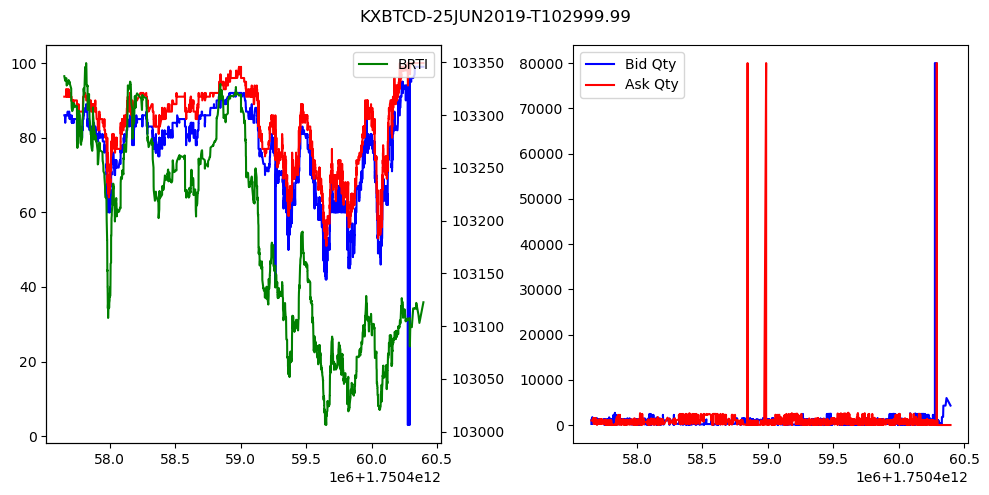

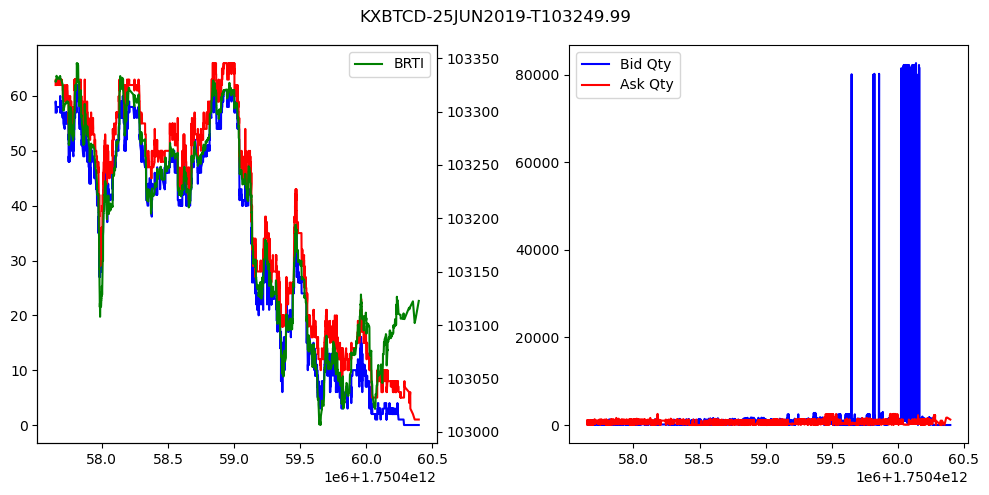

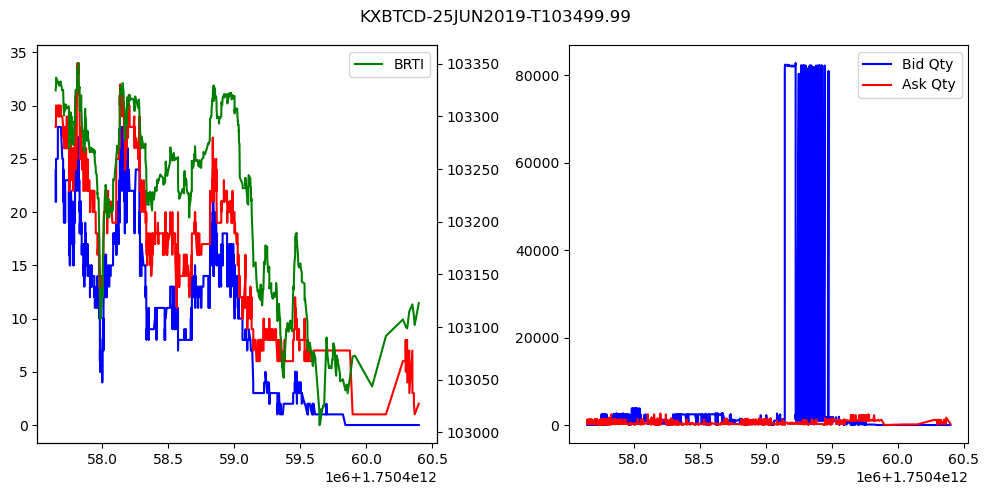

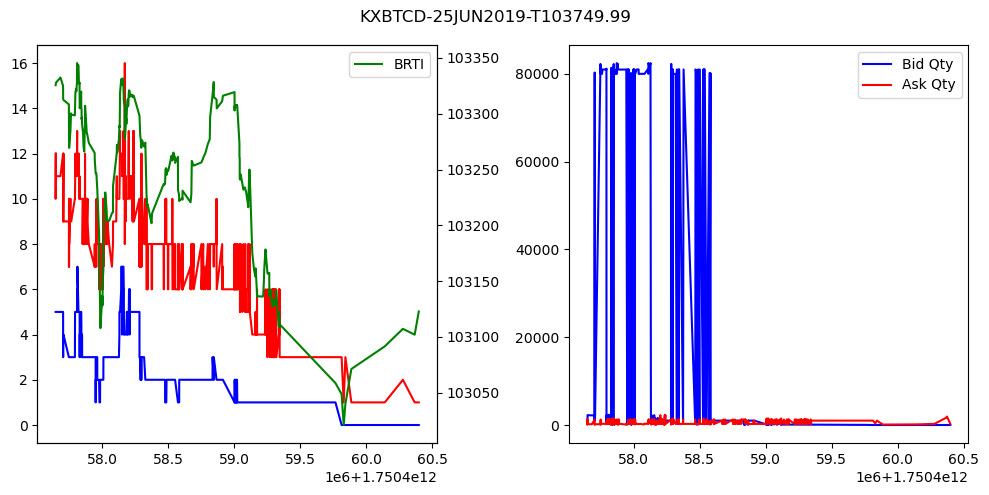

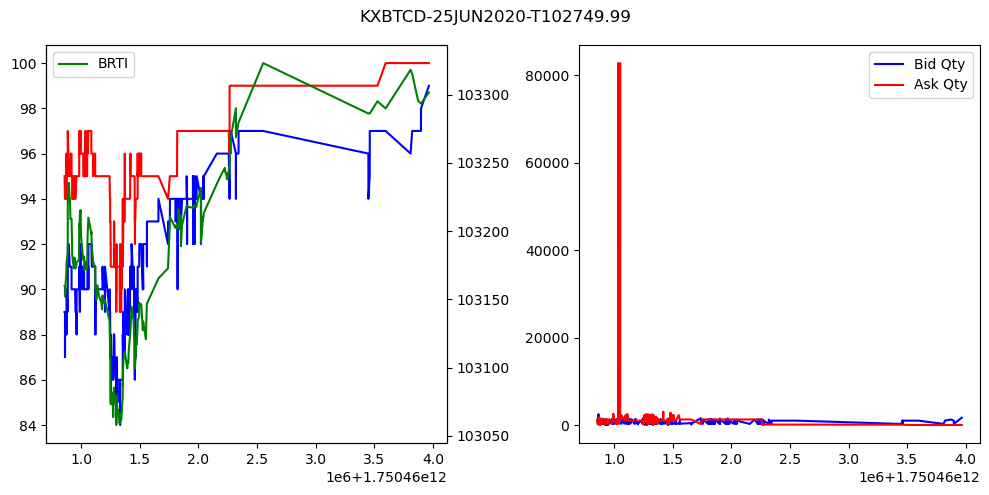

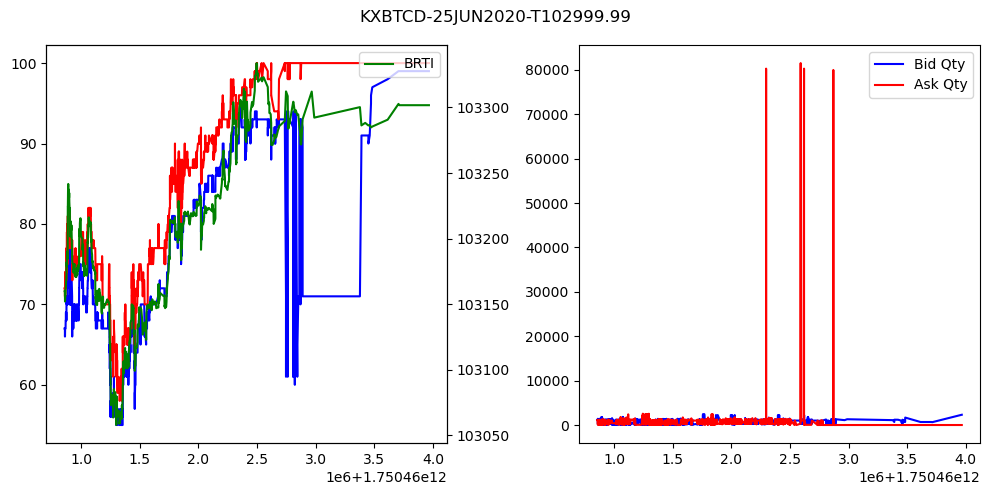

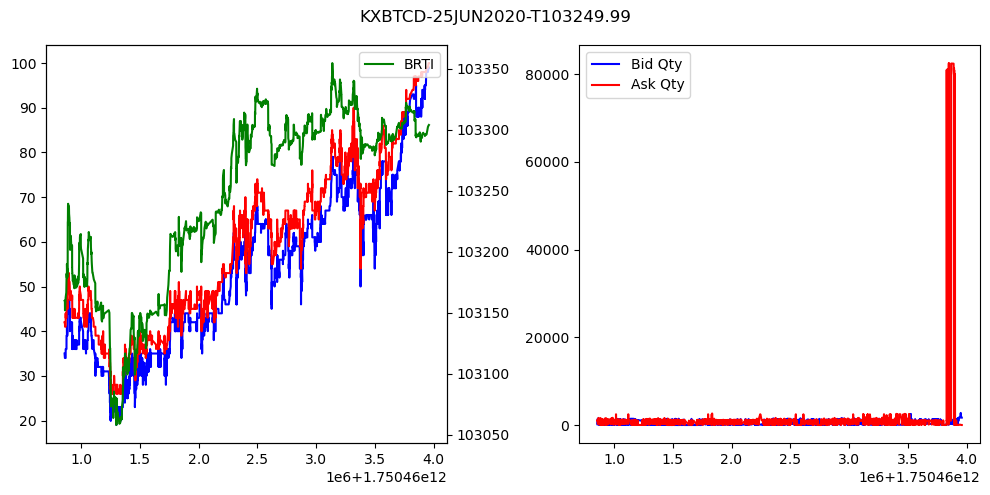

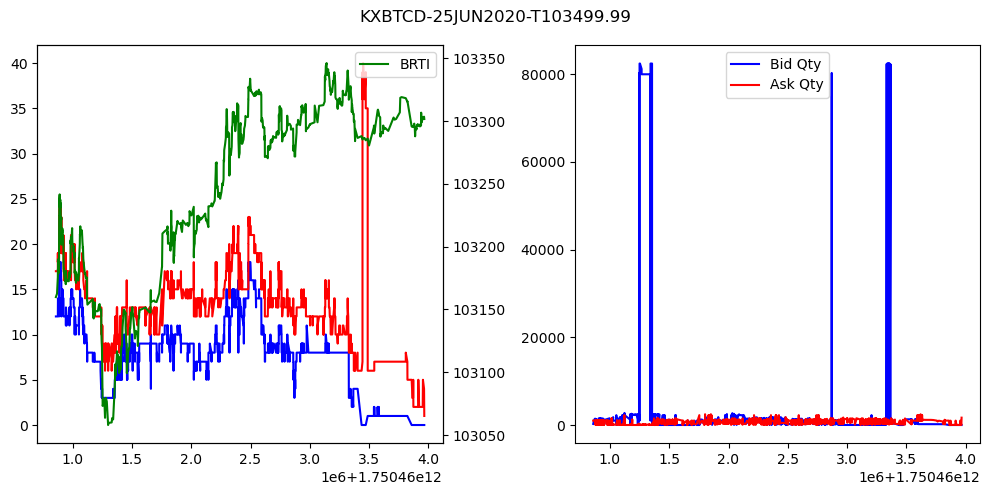

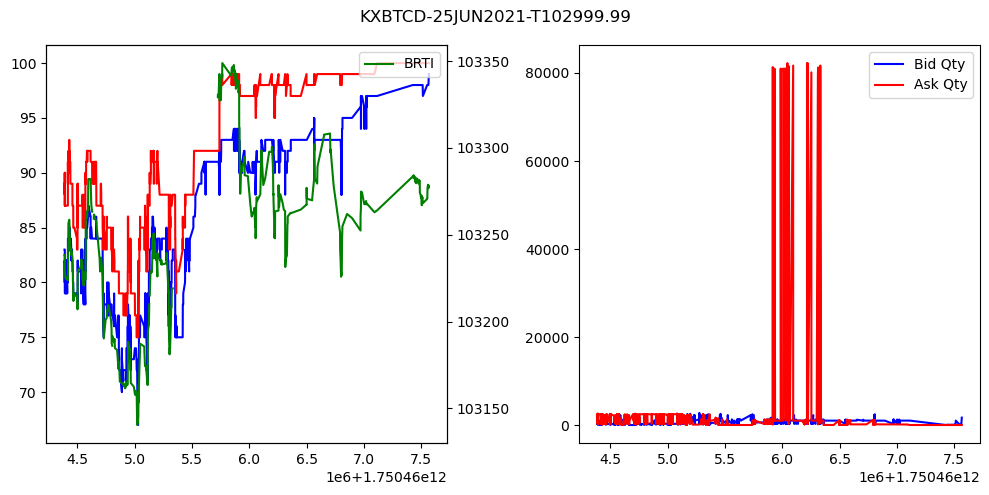

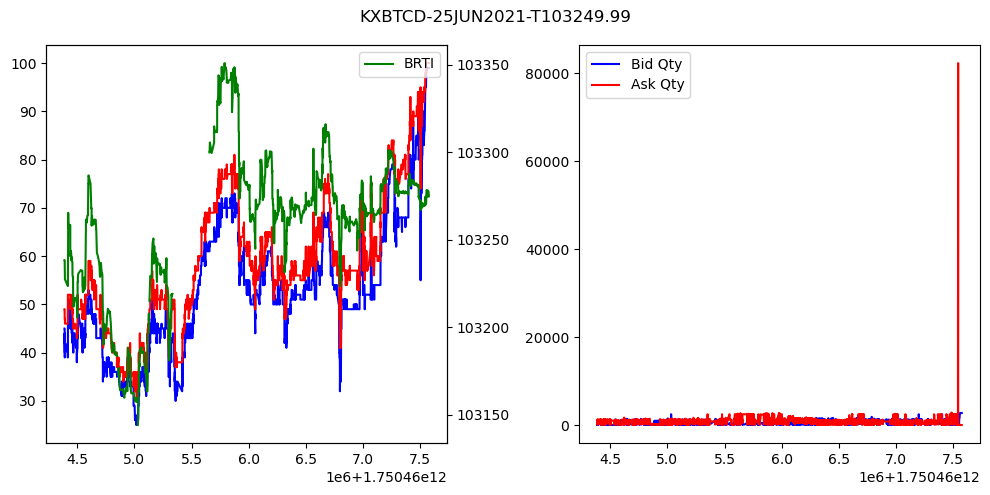

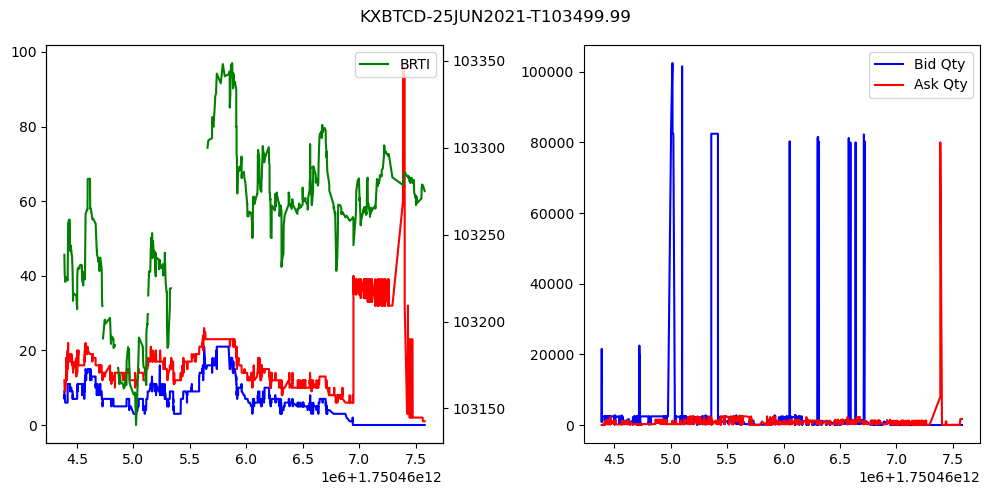

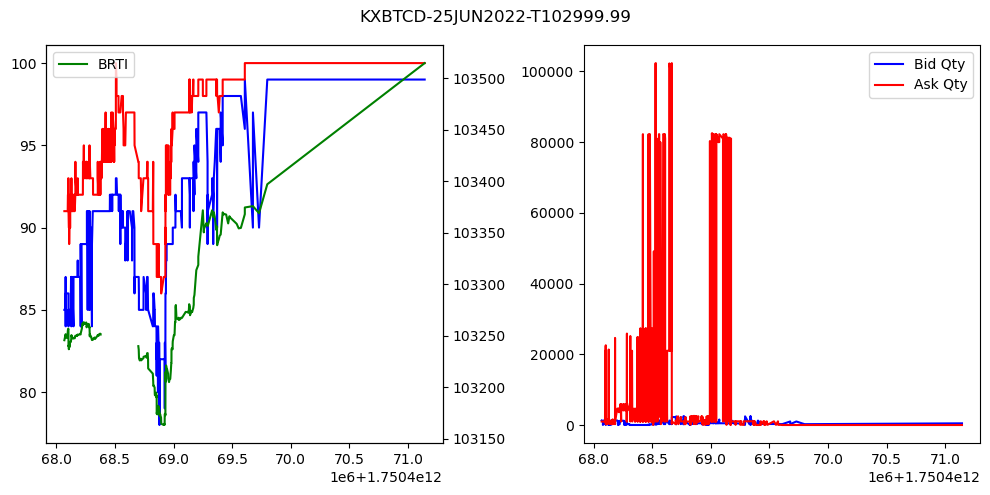

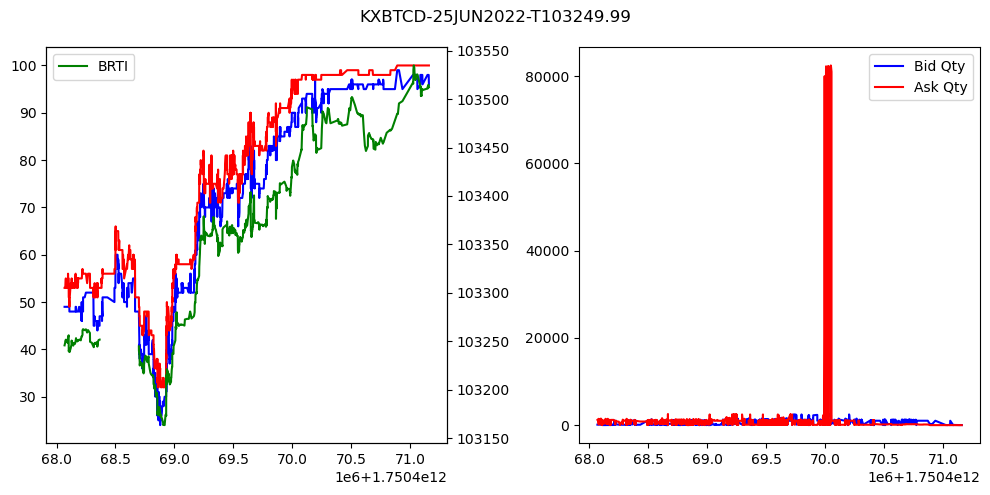

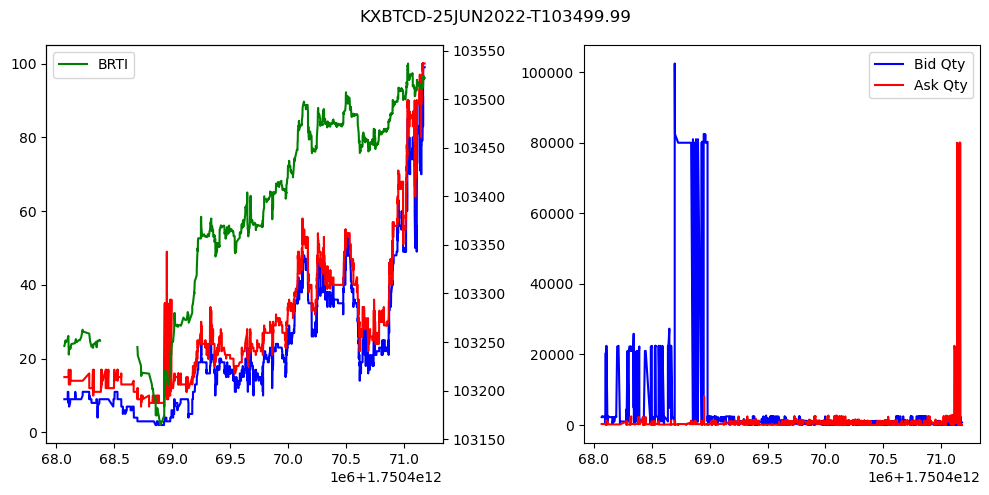

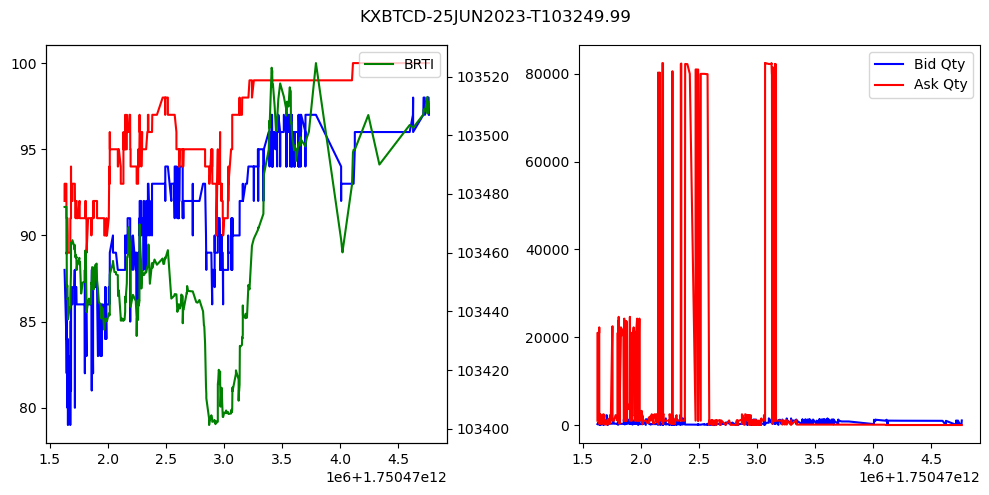

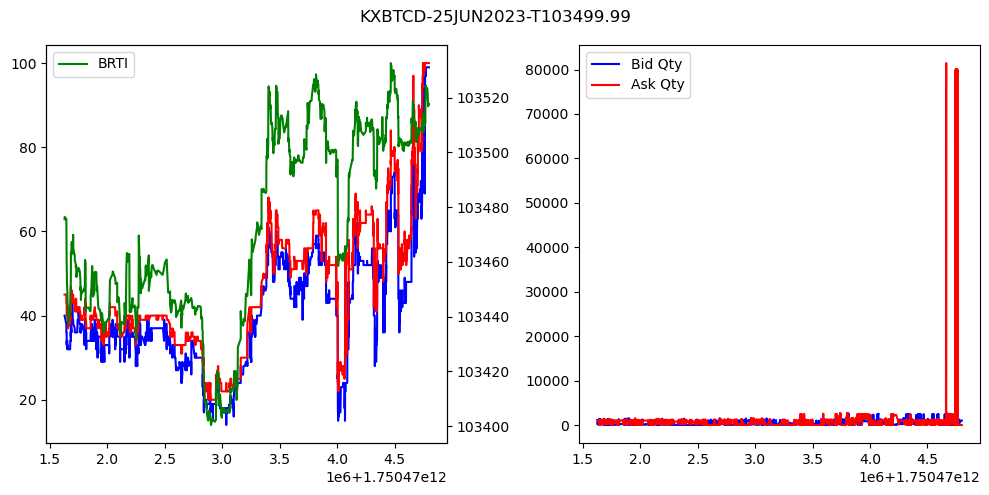

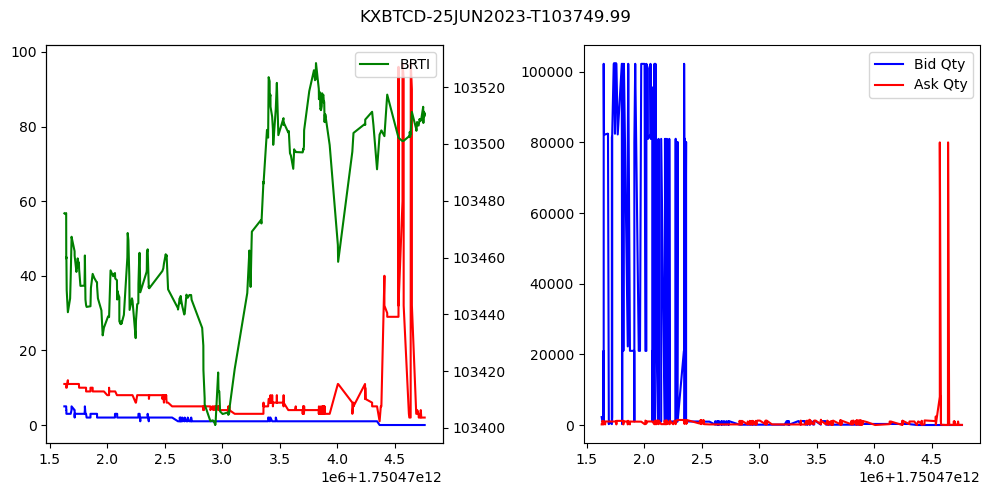

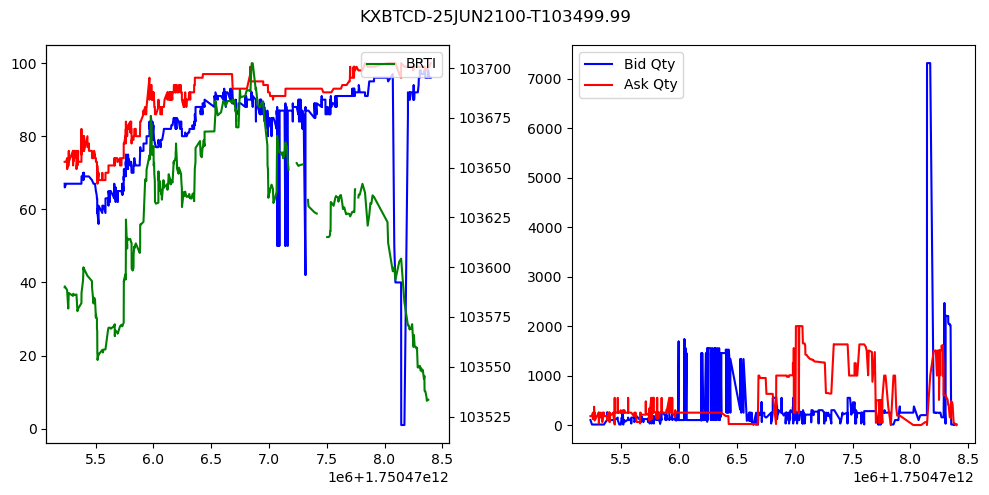

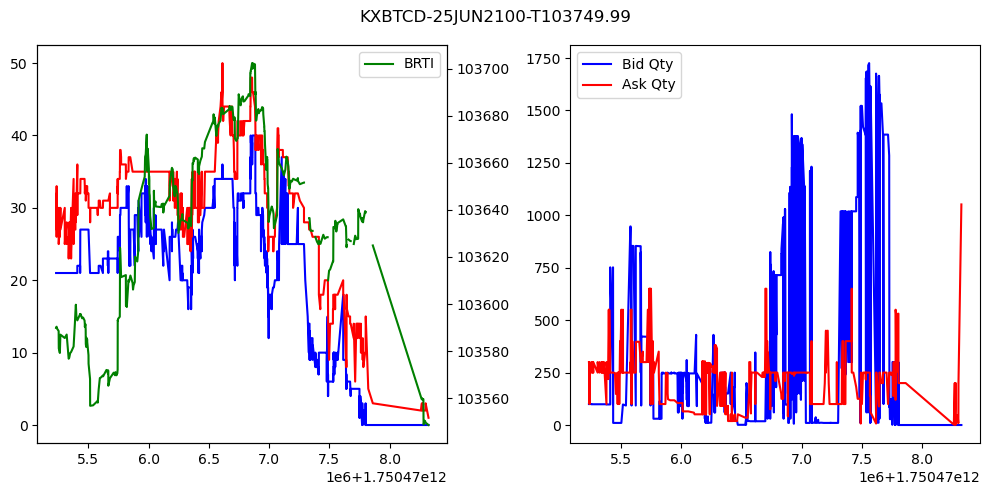

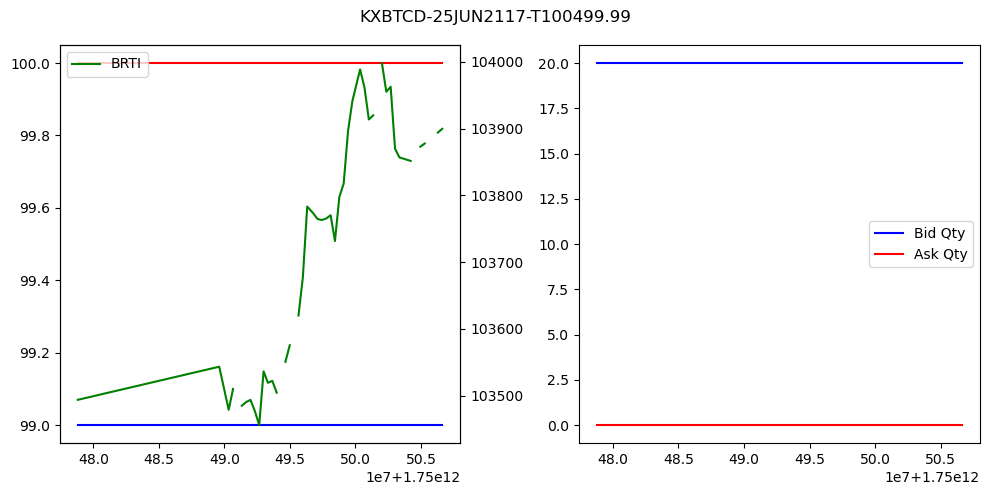

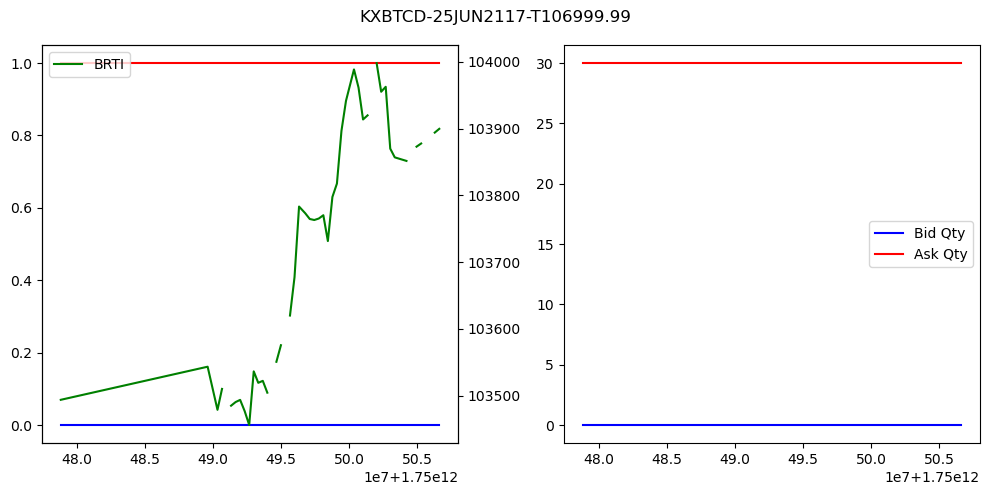

In [446]:
for key in quality_tickers.keys():
    group_df = quality_tickers[key]

    bid = group_df['best_bid']
    ask = group_df['best_ask']
    bid_qty = group_df['best_bid_qty']
    ask_qty = group_df['best_ask_qty']
    timestamp = group_df['timestamp_ms']
    brti = group_df['brti_price']
    ticker = key

    # plot it
    plt.figure(figsize=(10, 5))
    plt.suptitle(ticker)
    plt.subplot(1, 2, 1)
    plt.plot(timestamp, bid, c='blue', label='Bid')
    plt.plot(timestamp, ask, c='red', label='Ask')
    plt.twinx()
    plt.plot(timestamp, brti, c='green', label='BRTI')

    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(timestamp, bid_qty, c='blue', label='Bid Qty')
    plt.plot(timestamp, ask_qty, c='red', label='Ask Qty')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [449]:
from scipy.stats import norm

def binary_call_price(S, K, T, sigma, r=0.0):
    """
    Calculates the Black-Scholes price for a cash-or-nothing binary call option.

    Args:
        S (float): Current price of the underlying asset.
        K (float): Strike price of the option.
        T (float): Time to expiration in years.
        r (float): Annualized risk-free interest rate.
        sigma (float): Annualized volatility.

    Returns:
        float: The theoretical price of the binary call option (per $1 of payoff).
    """
    # To prevent division by zero errors if T or sigma are zero
    if T <= 0 or sigma <= 0:
        return 1.0 if S > K else 0.0

    # Calculate d2
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    
    # Calculate the price using the formula
    price = np.exp(-r * T) * norm.cdf(d2)
    
    return price

In [450]:
quality_tickers.keys()

quality_tickers['KXBTCD-25JUN2019-T102999.99'].tail()

,timestamp_ms,ticker,best_bid,best_bid_qty,best_ask,best_ask_qty,expiration,tte,brti_price
199805,1750457658239,KXBTCD-25JUN2019-T102999.99,85,1000,91,1000,1750460400000,0.761600,103332.50
199806,1750457658198,KXBTCD-25JUN2019-T102999.99,84,1740,91,1000,1750460400000,0.761612,103332.50
199807,1750457658122,KXBTCD-25JUN2019-T102999.99,86,1000,91,1000,1750460400000,0.761633,103332.50
199892,1750457651299,KXBTCD-25JUN2019-T102999.99,86,1250,91,1000,1750460400000,0.763528,103336.74
199894,1750457651139,KXBTCD-25JUN2019-T102999.99,86,250,91,1000,1750460400000,0.763572,103336.74


In [793]:
import pandas as pd
import numpy as np
from arch import arch_model
import warnings

# Suppress convergence warnings from the GARCH model fitting process
warnings.filterwarnings("ignore", category=UserWarning, module='arch')

# --- Function 1: The Core GARCH Volatility Forecaster ---
def get_garch_volatility_forecast(price_series, horizon_seconds=3600, p=1, q=1):
    """
    Calculates the average annualized volatility forecast over a future period
    using a GARCH(1,1) model.
    """
    if not isinstance(price_series.index, pd.DatetimeIndex):
        raise TypeError("The price_series index must be a DatetimeIndex.")
        
    returns = 100 * price_series.pct_change().dropna()
    
    if len(returns) < 200:
        return np.nan

    model = arch_model(returns, vol='Garch', p=p, q=q, dist='t')
    
    try:
        fit_result = model.fit(disp='off', show_warning=False)
    except Exception:
        return np.nan
    
    # get conditional volatility series from fitted model
    conditional_vol_series = fit_result.conditional_volatility
    # calculate vol series
    vol_of_vol = conditional_vol_series.std() / 100


    forecast = fit_result.forecast(horizon=horizon_seconds, reindex=False)
    mean_forecast_variance = forecast.variance.iloc[-1].mean()
    avg_vol_per_second = np.sqrt(mean_forecast_variance) / 100.0
    
    seconds_in_year = 365.25 * 24 * 60 * 60
    annualized_vol = avg_vol_per_second * np.sqrt(seconds_in_year)
    
    return annualized_vol, vol_of_vol

# --- Function 2: The New Wrapper Function You Requested ---
def analyze_option_volatility(current_timestamp_ms, future_timestamp_ms, lookback_period_str, brti_df_indexed):
    """
    Fits a GARCH model on recent data to forecast volatility for a specific option lifetime.

    Args:
        current_timestamp_ms (int): The current time (or time of analysis) in milliseconds.
        future_timestamp_ms (int): The option's expiration timestamp in milliseconds.
        lookback_period_str (str): The amount of historical data to use for fitting,
                                   e.g., '4H', '2H', '30T'.
        brti_df_indexed (pd.DataFrame): The BRTI DataFrame with a DatetimeIndex.

    Returns:
        float: The single, annualized GARCH volatility forecast, or np.nan if it fails.
    """
    # 1. Calculate the forecast horizon in seconds
    horizon_seconds = (future_timestamp_ms - current_timestamp_ms) / 1000
    
    if horizon_seconds <= 0:
        print("Warning: Future timestamp must be after current timestamp.")
        return np.nan

    # 2. Define the lookback window for slicing the data
    # Convert the current time to a pandas Timestamp for slicing
    current_time = pd.to_datetime(current_timestamp_ms, unit='ms')
    lookback_start_time = current_time - pd.Timedelta(lookback_period_str)
    
    # Slice the historical data based on the lookback window
    price_window = brti_df_indexed['brti_price'][lookback_start_time:current_time]

    # print(f"Analyzing option from {current_time.strftime('%Y-%m-%d %H:%M:%S')}")
    # print(f"  - Fitting model on data from the last {lookback_period_str} ({len(price_window)} points).")
    # print(f"  - Forecasting volatility for the next {horizon_seconds/60:.1f} minutes.")
    
    # 3. Call the core GARCH function with the sliced data and calculated horizon
    forecast, vol_of_vol = get_garch_volatility_forecast(
        price_series=price_window,
        horizon_seconds=int(horizon_seconds) # Ensure it's an integer
    )
    
    return forecast, vol_of_vol

df_brti_indexed = df_brti.copy()
print("Preparing data...")
df_brti_indexed = df_brti_indexed.sort_values('timestamp_ms').copy()
df_brti_indexed['datetime'] = pd.to_datetime(df_brti['timestamp_ms'], unit='ms')
df_brti_indexed = df_brti_indexed.set_index('datetime')

realized_vol_forecast, vol_of_vol = analyze_option_volatility(1750457575340, 1750460400000, '24H', df_brti_indexed)

print(realized_vol_forecast*100)

S0 = 103362.50
K = 102999.99
T  = (0.784628) / 24

print(f"brti: {S0}")
print(f"strike: {strike}")
print(f"tte: {T}")
print(f"realized vol: {realized_vol_forecast*100}%")
print(f'start: {1750457575340} end: {1750460400000}')

price = binary_call_price(S0, K, T, realized_vol_forecast)

# print stuff
print(f"Realized Volatility Forecast: {realized_vol_forecast*100}%")
print(f"Binary Call Price: {price}")

if not np.isnan(realized_vol_forecast):
    print(f"Realized Volatility Forecast: {realized_vol_forecast * 100:.2f}%")
    print(f"Volatility of Volatility: {vol_of_vol * 100:.4f}%")
else:
    print("GARCH model fitting failed.")


Preparing data...
37.27649258479811
brti: 103362.5
strike: 106999.99
tte: 0.03269283333333333
realized vol: 37.27649258479811%
start: 1750457575340 end: 1750460400000
Realized Volatility Forecast: 37.27649258479811%
Binary Call Price: 0.5073506396043413
Realized Volatility Forecast: 37.28%
Volatility of Volatility: 0.0025%


C:\Users\chris\AppData\Local\Temp\ipykernel_24916\1298470194.py:70: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  lookback_start_time = current_time - pd.Timedelta(lookback_period_str)
c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.454e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [788]:
for key in quality_tickers.keys():
    print(quality_tickers[key]['realized_vol'].max())


0.23101168636096278
0.23608017040510135
0.23373202985213795
0.23165655199958538
0.16586161903358237
0.17665157710205012
0.15955605542141796
0.15923835628707747
0.17043946736089946
0.1557026532397847
0.17043946736089946
0.1421361124897935
0.13523064599684037
0.13321180365750201
0.10253778242234568
0.10257137566719914
0.10251607678550696
0.12461793446491465
0.12489123972111439
16.988988446380702
16.988988446380702


# calculate price using garch model

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.123e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


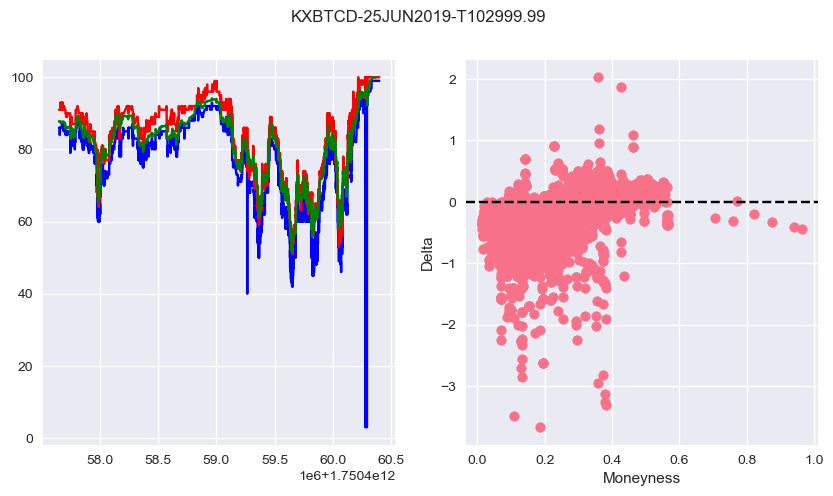

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.122e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


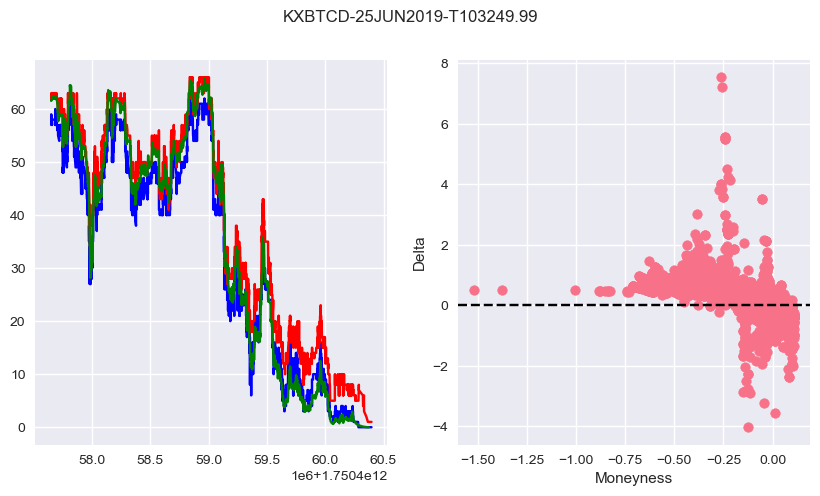

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.123e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


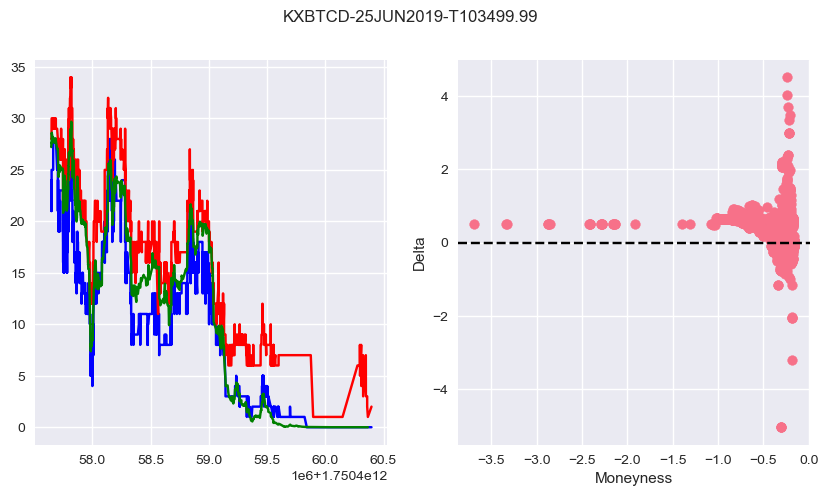

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 4.123e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


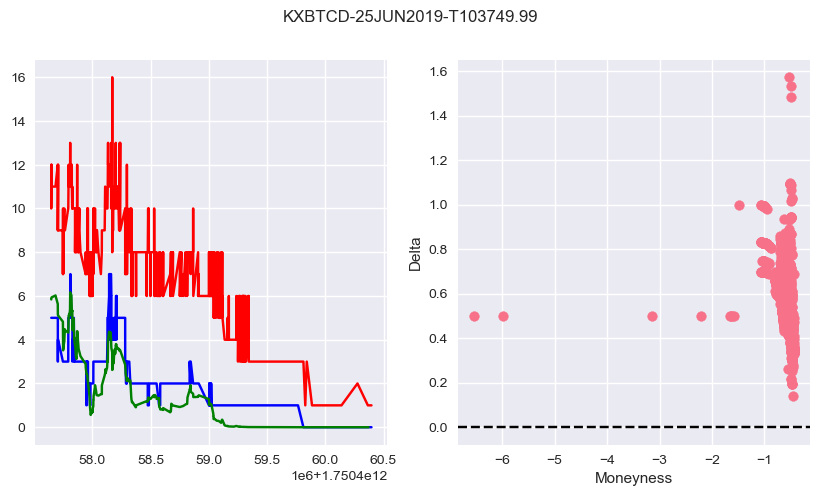

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.714e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


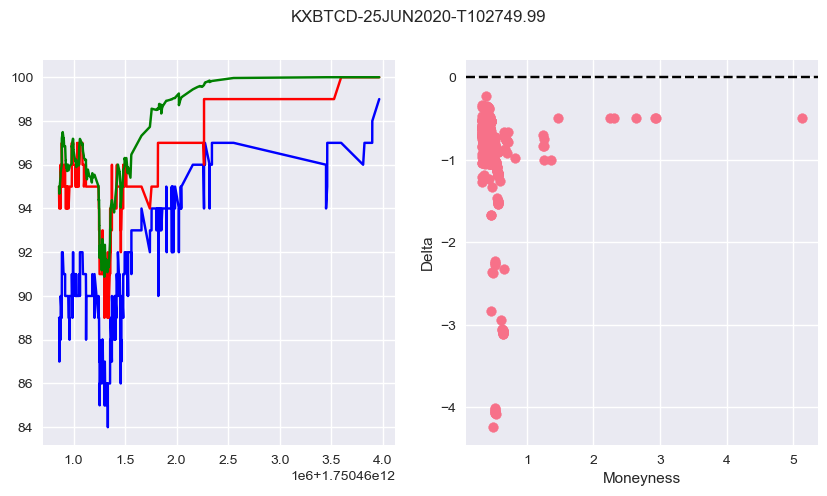

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.714e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


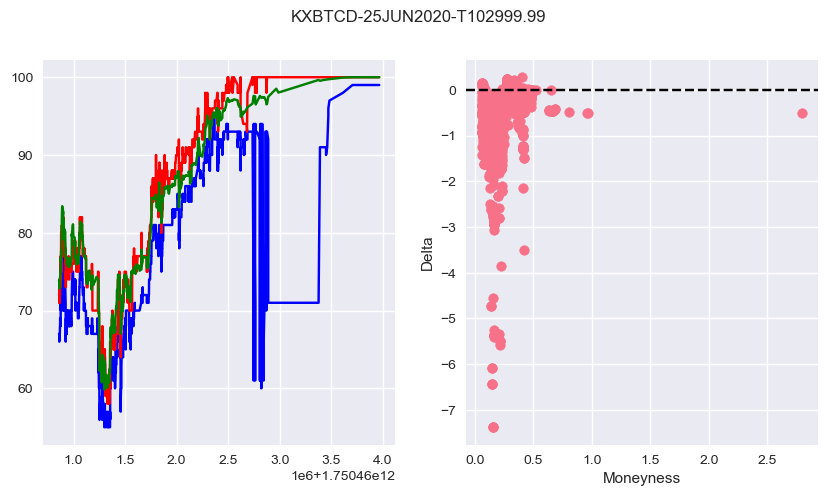

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.715e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


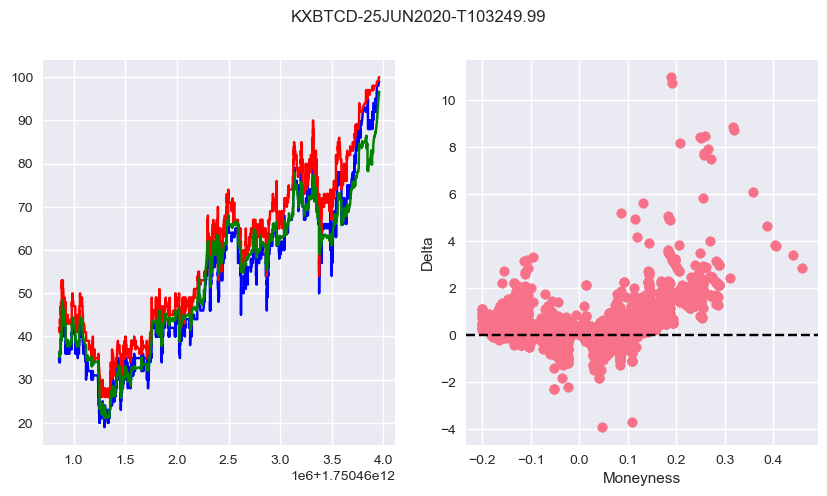

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.714e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


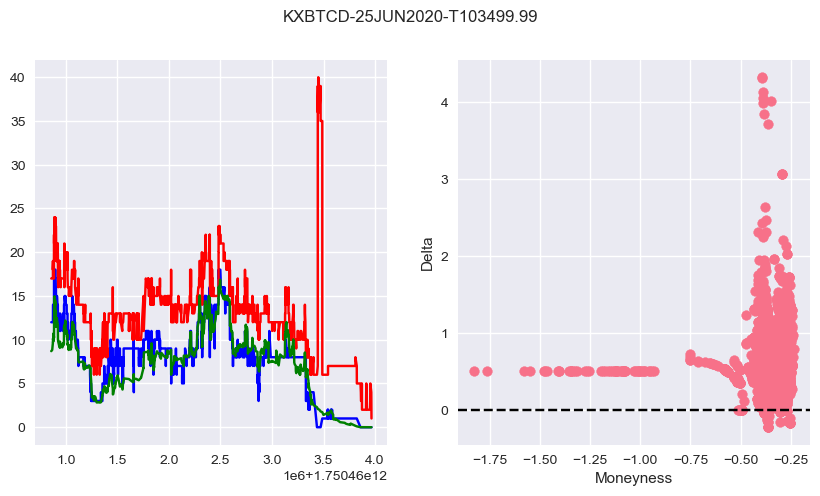

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.502e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


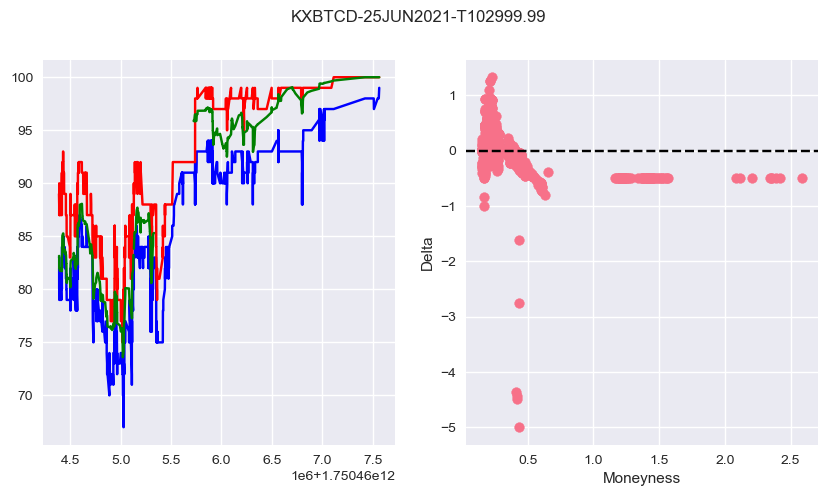

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.501e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


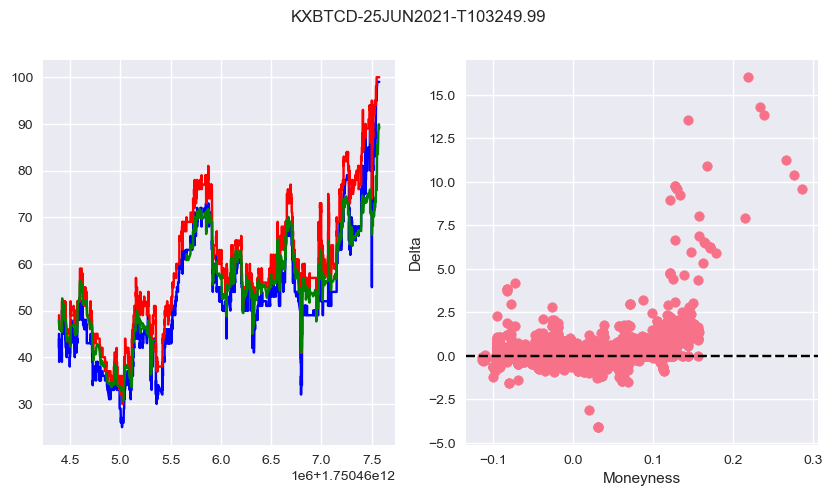

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.5e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


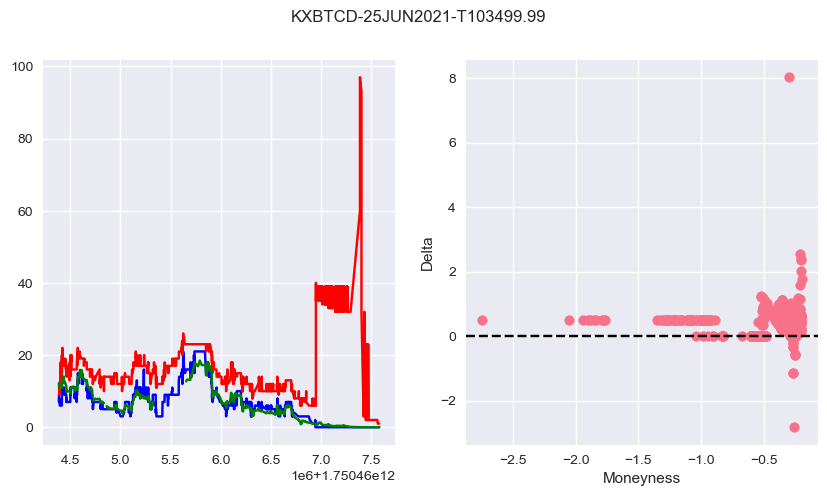

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.22e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


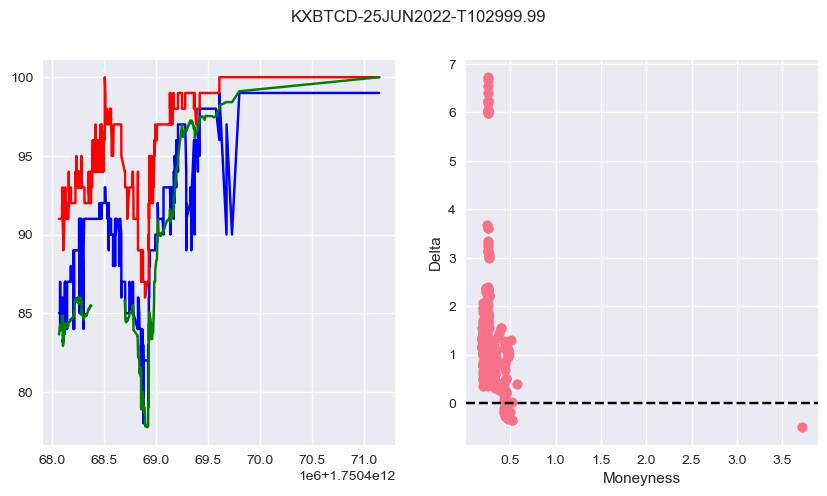

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.218e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


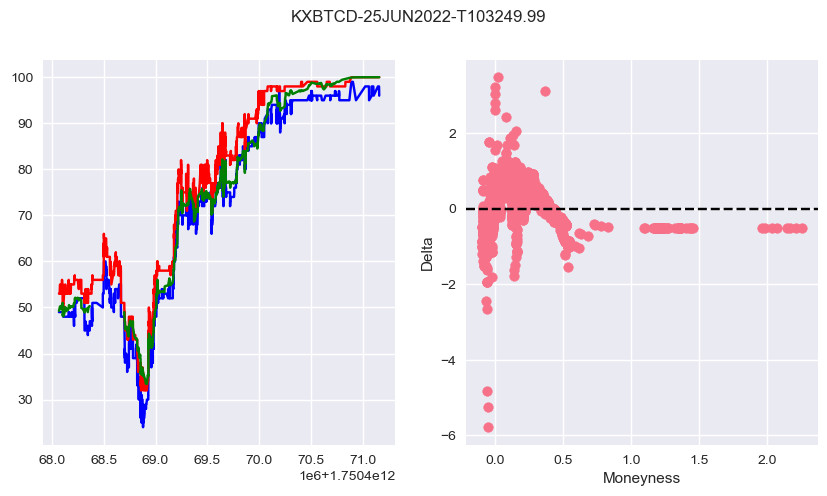

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 3.217e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


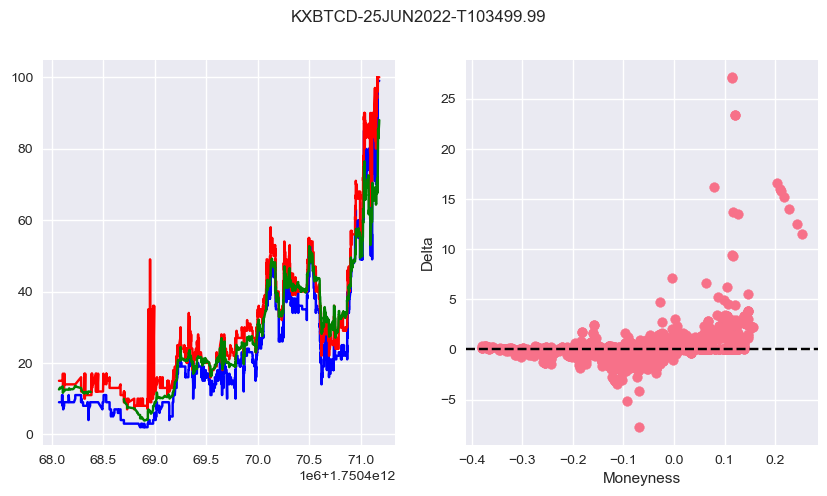

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.94e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


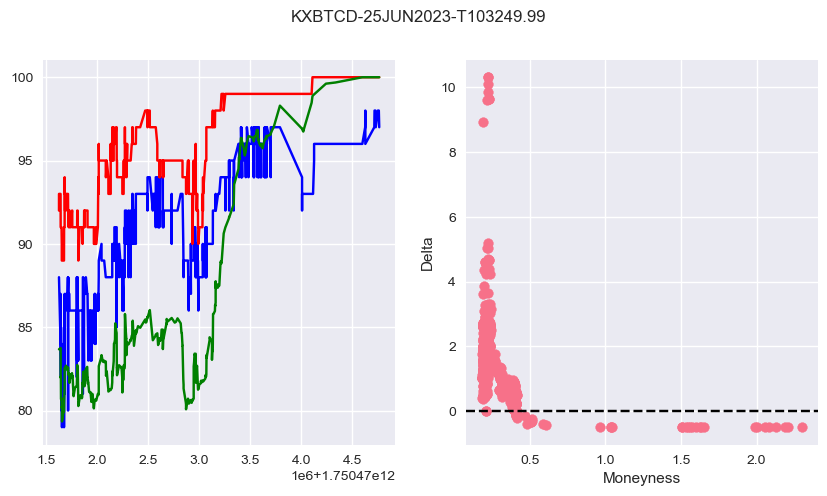

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.938e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


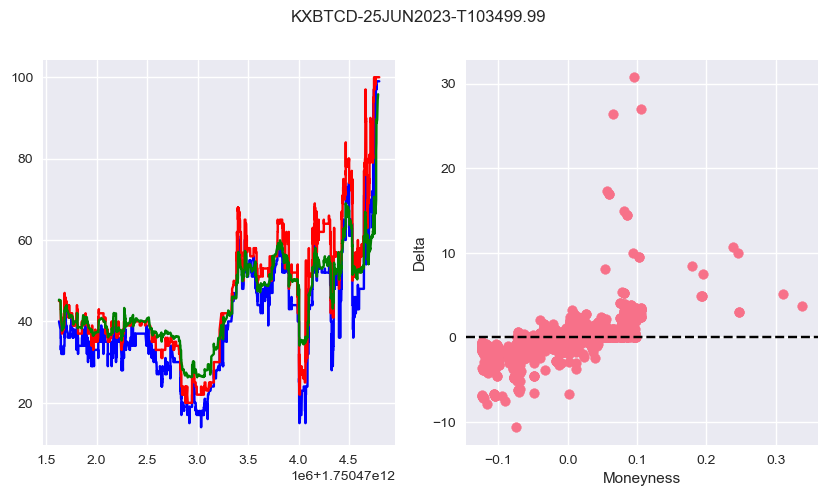

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.94e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


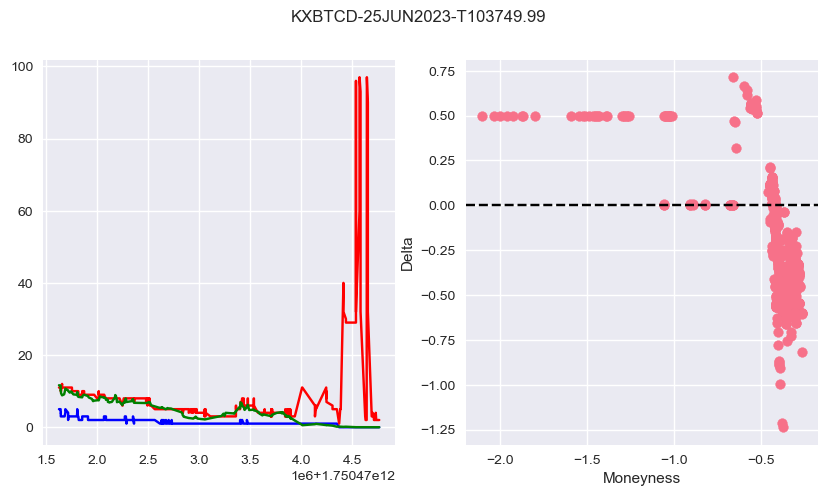

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.787e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


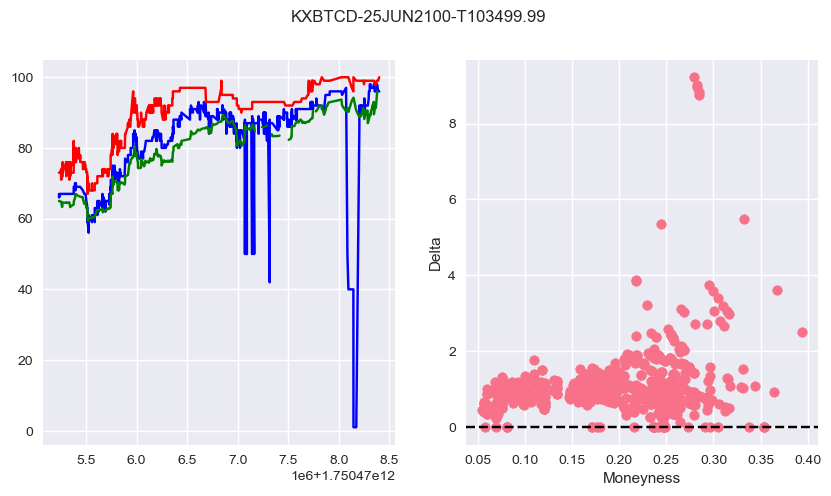

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.789e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


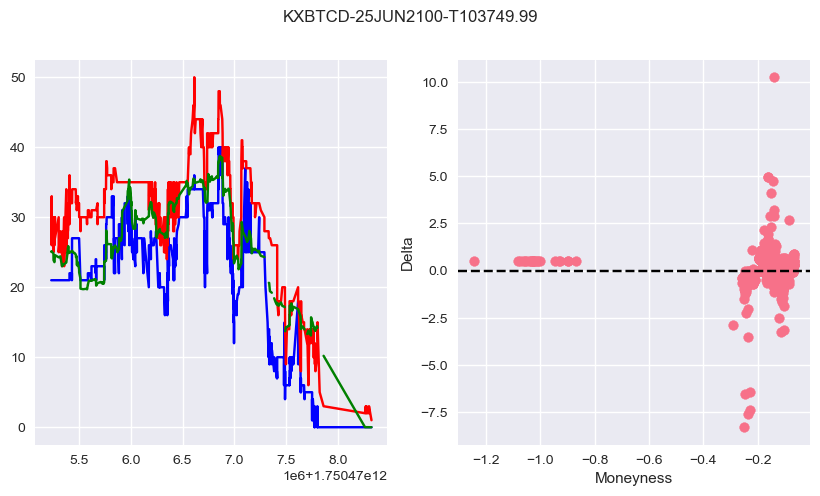

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.336e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


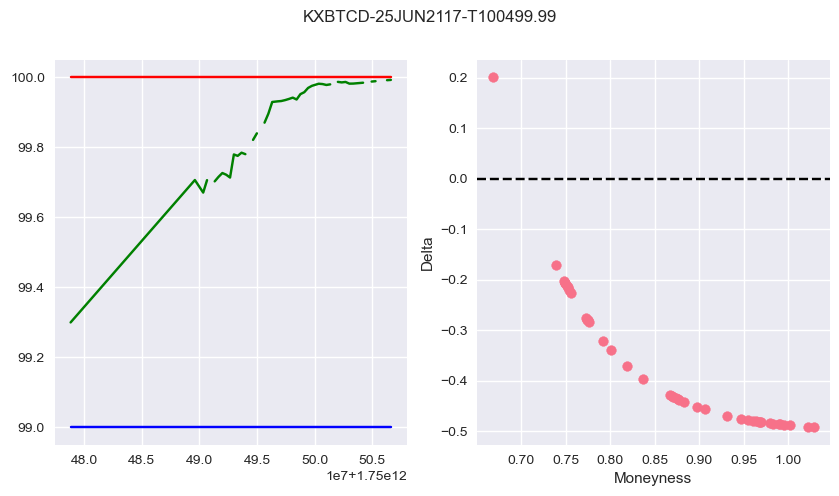

c:\Users\chris\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.336e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


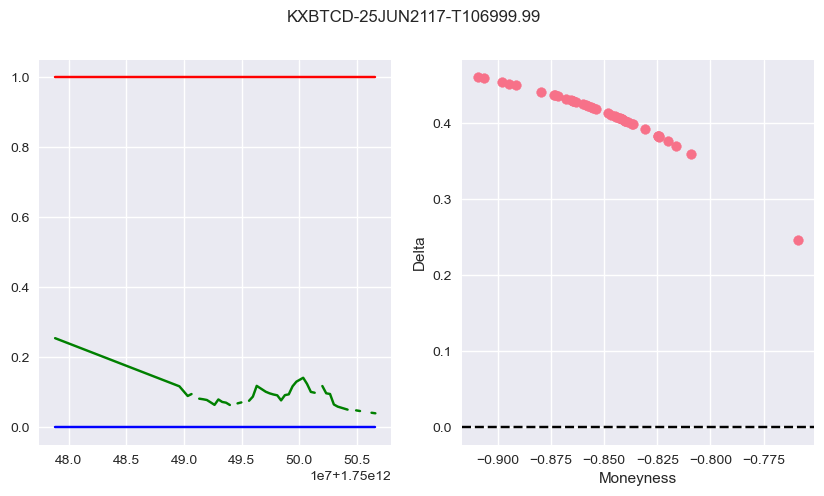

In [825]:
for ticker in quality_tickers.keys():
    prices = []
    realized_vols = []
    calculated_vol = []
    vol_of_vols = []

    # every 10 rows recalculate the volatility
    counter = 0
    current_vol = None
    vol_of_vol = None

    for row in quality_tickers[ticker].iterrows():
        strike = get_strike(row[1]['ticker'])
        tte = row[1]['tte'] / 24 / 365 # in hours, convert to years
        brti_price = row[1]['brti_price']

        current_ms = row[1]['timestamp_ms']
        expiration_ms = row[1]['expiration']

        if current_vol is None:
            if abs(current_ms - expiration_ms) > 10 * 1000: # ensure not super close to expiration
                current_vol, vol_of_vol = analyze_option_volatility(current_ms, expiration_ms, '24h', df_brti_indexed)
            else:
                prices.append(None)
                realized_vols.append(None)
                vol_of_vols.append(None)
                continue

        elif current_vol % 30 == 0:
            if abs(current_ms - expiration_ms) > 30 * 1000: # ensure not super close to expiration
                current_vol, vol_of_vol = analyze_option_volatility(current_ms, expiration_ms, '24h', df_brti_indexed)
        
        counter += 1        

        price = binary_call_price(brti_price, strike, tte, current_vol) * 100
        prices.append(price)
        realized_vols.append(current_vol)
        vol_of_vols.append(vol_of_vol)

    quality_tickers[ticker]['realized_vol'] = realized_vols
    quality_tickers[ticker]['binary_price'] = prices
    quality_tickers[ticker]['vol_of_vol'] = vol_of_vols

    mid_price = (quality_tickers[ticker]['best_bid'] + quality_tickers[ticker]['best_ask']) / 2

    spread = (quality_tickers[ticker]['best_ask'] - quality_tickers[ticker]['best_bid'])

    # make spread 10000 if spread > 12
    spread = np.where(spread > 12, 10000, spread)

    deltas = (mid_price - quality_tickers[ticker]['binary_price']) / spread



    moneyness = np.log(quality_tickers[ticker]['brti_price'] / get_strike(ticker)) / np.sqrt(quality_tickers[ticker]['tte'] / 24 / 365)

    bids = quality_tickers[ticker]['best_bid']
    asks = quality_tickers[ticker]['best_ask']

    plt.figure(figsize=(10, 5))
    plt.suptitle(ticker)
    plt.subplot(1, 2, 1)

    plt.plot(quality_tickers[ticker]['timestamp_ms'], bids, c='blue')
    plt.plot(quality_tickers[ticker]['timestamp_ms'], asks, c='red')

    plt.plot(quality_tickers[ticker]['timestamp_ms'], quality_tickers[ticker]['binary_price'], c='green')

    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(moneyness, deltas)
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Moneyness')
    plt.ylabel('Delta')
    plt.show()


# accounting for vol of vol

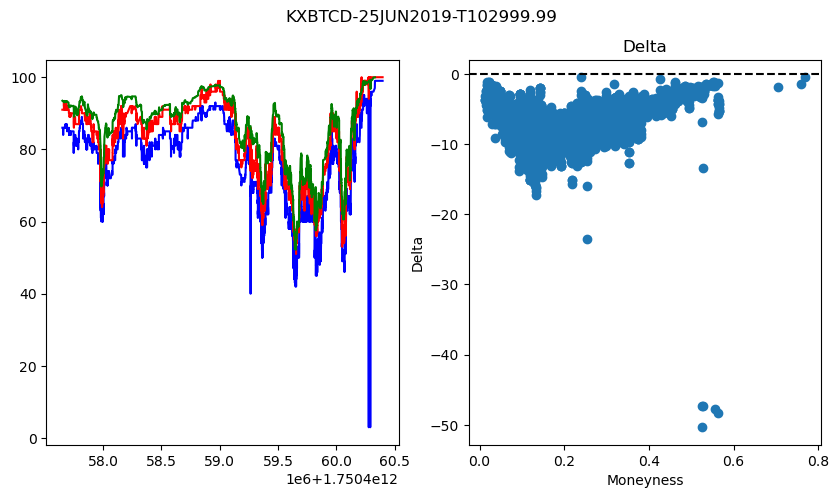

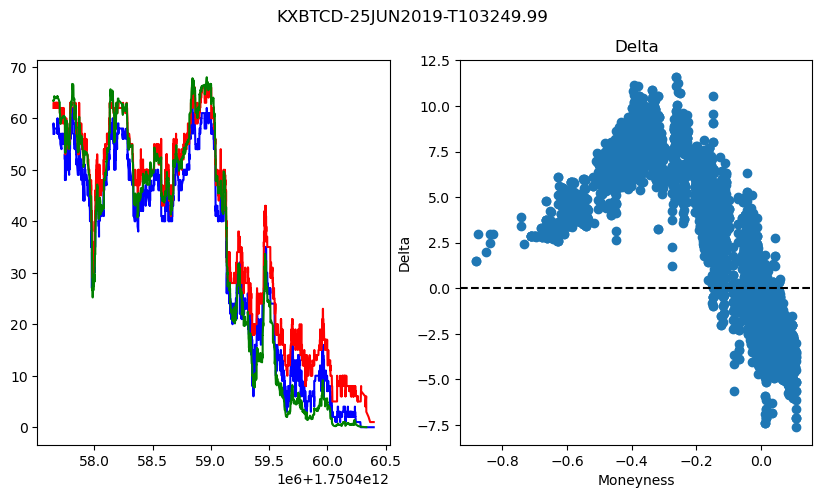

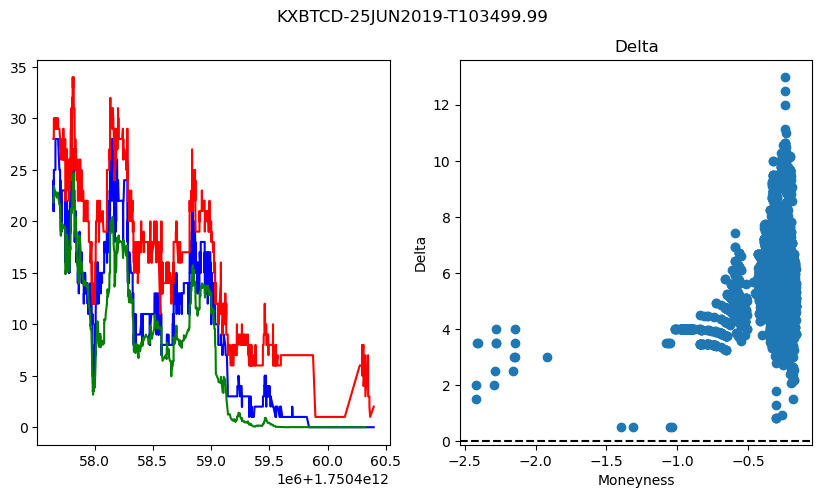

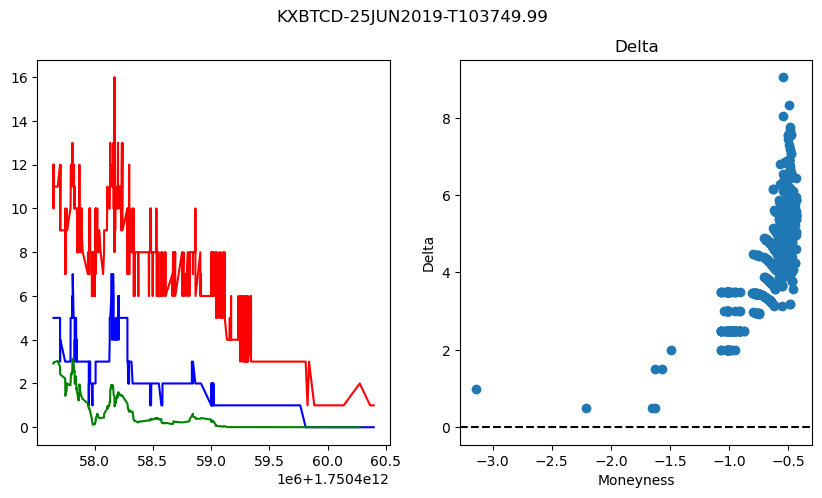

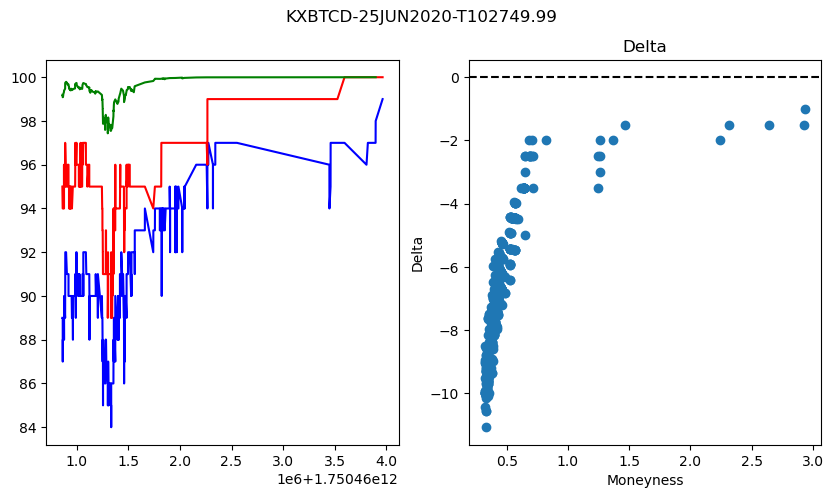

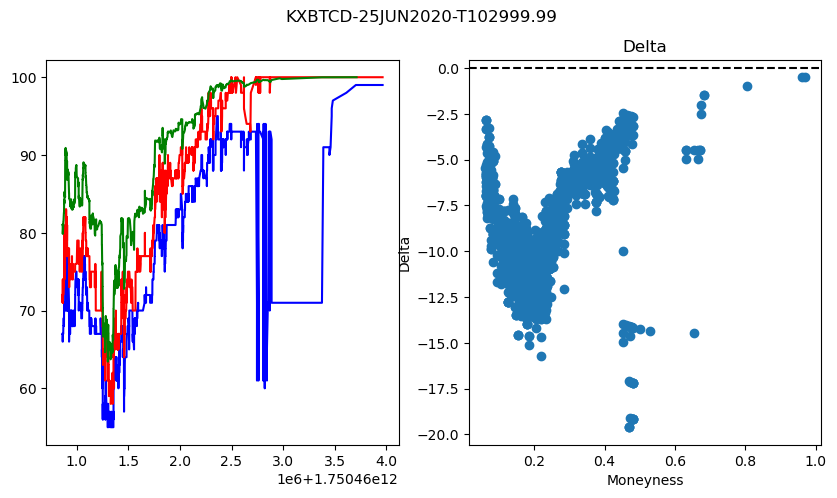

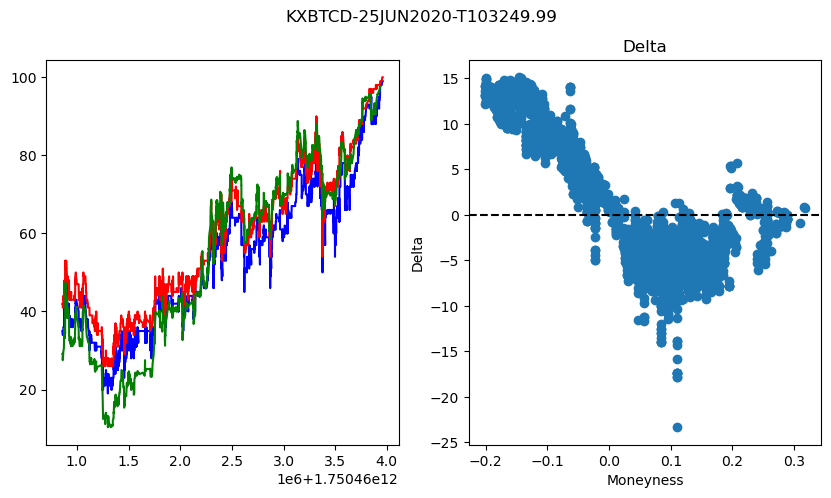

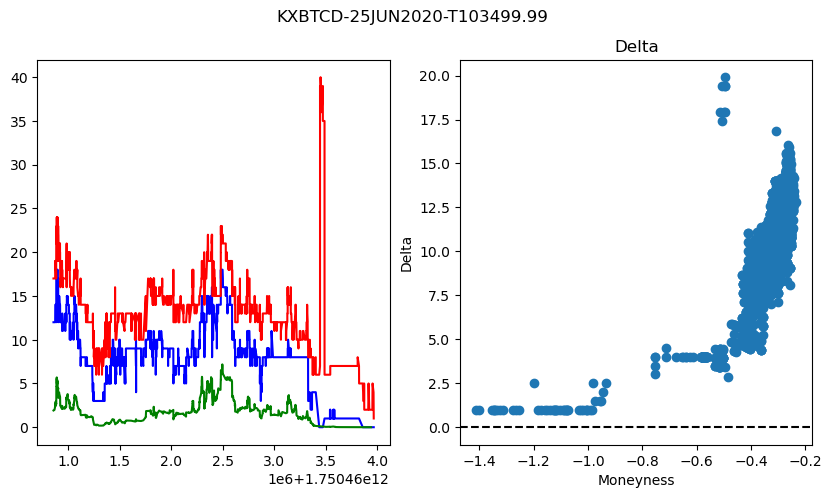

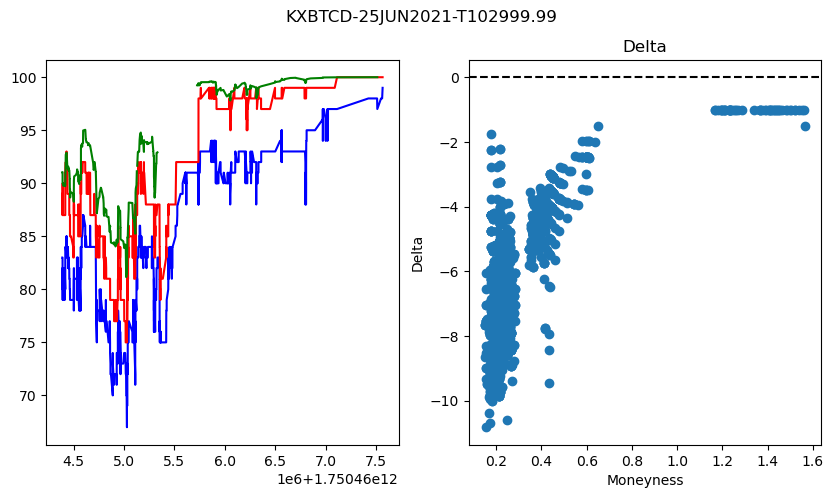

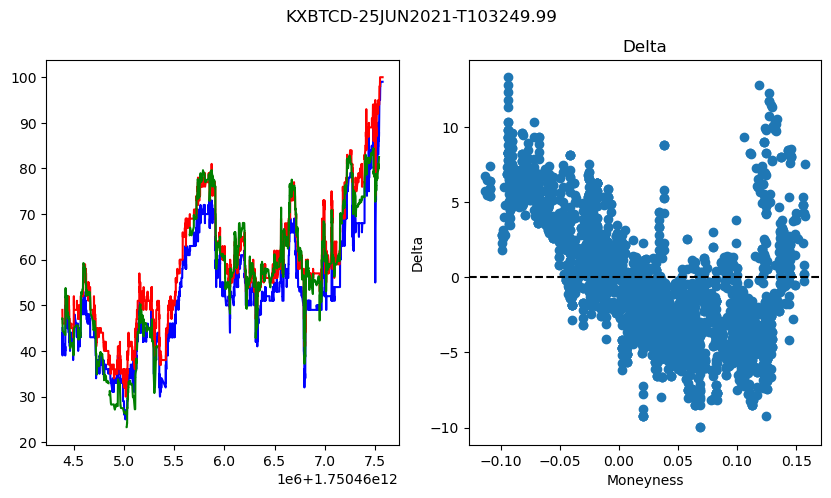

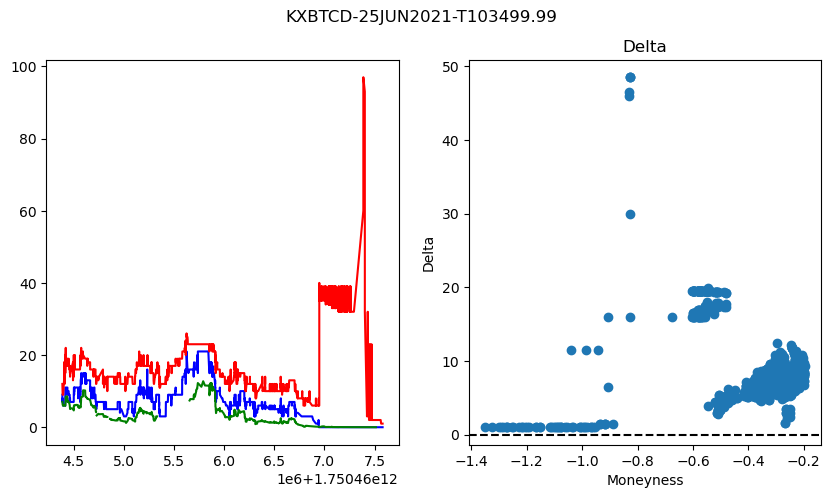

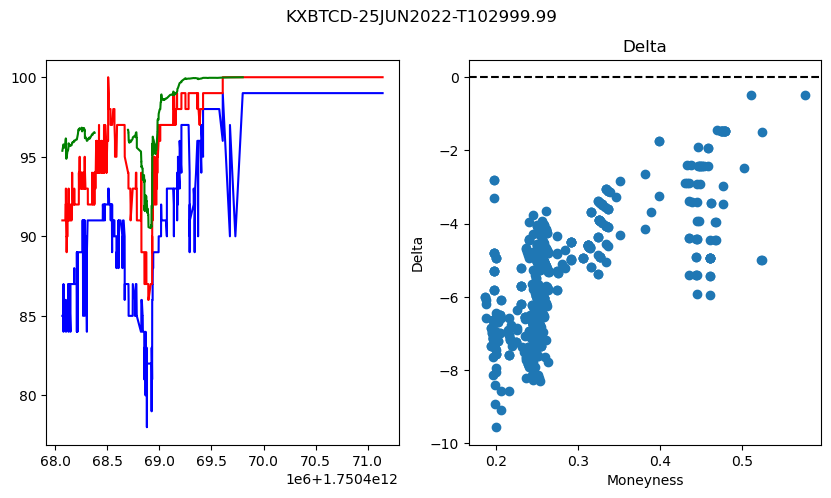

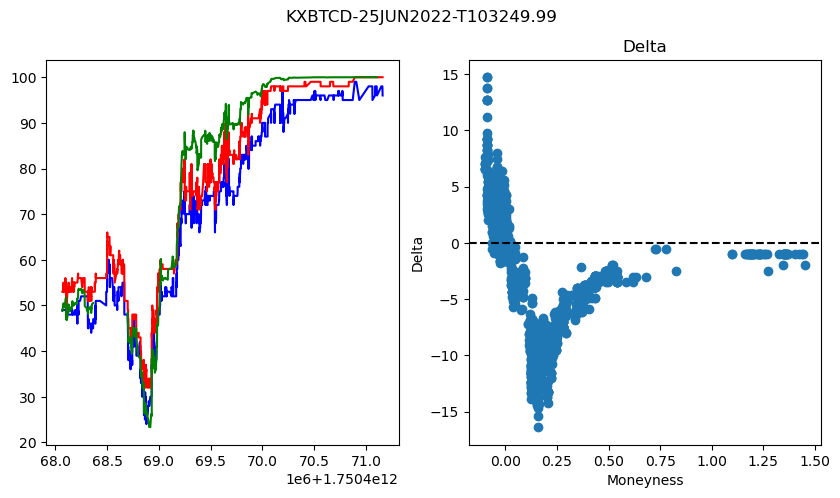

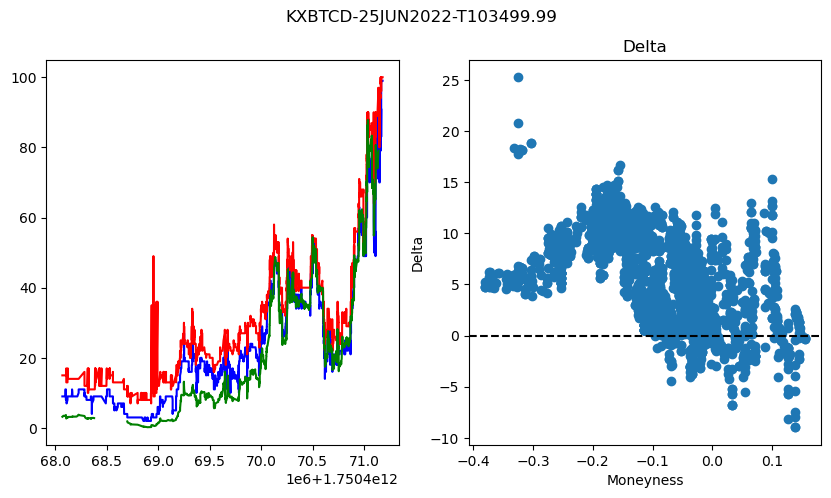

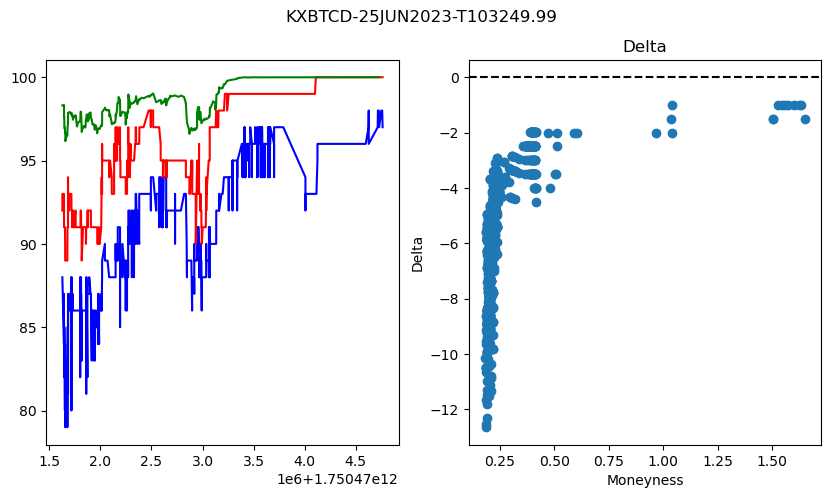

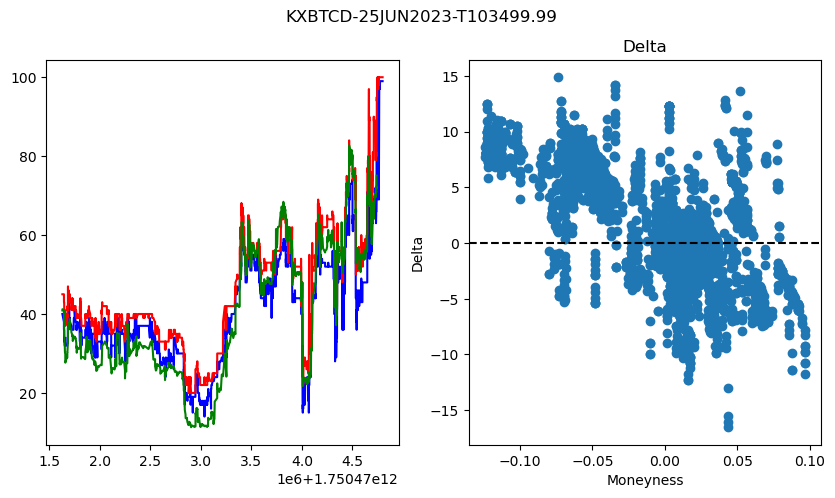

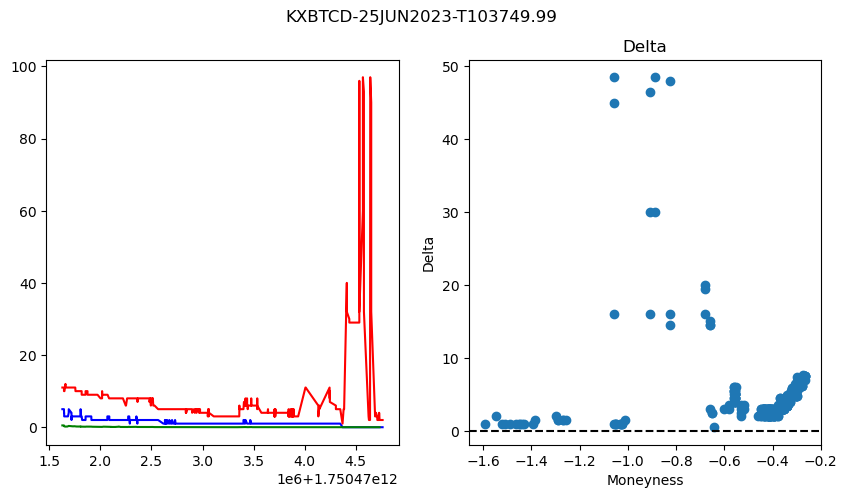

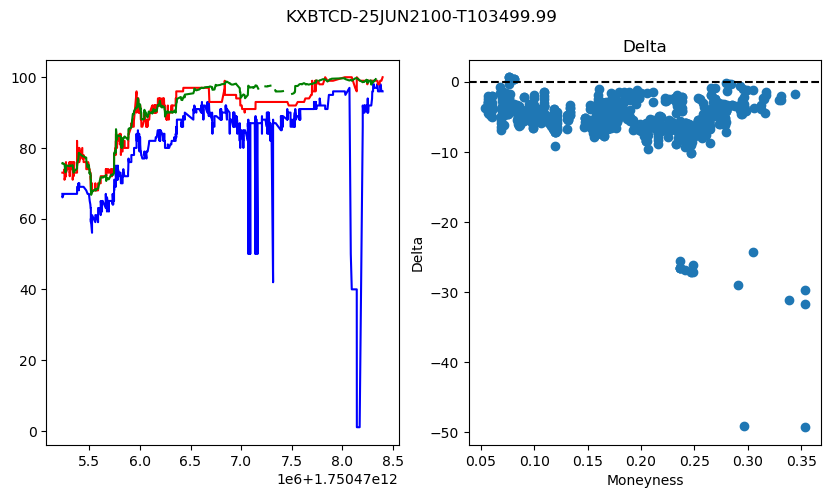

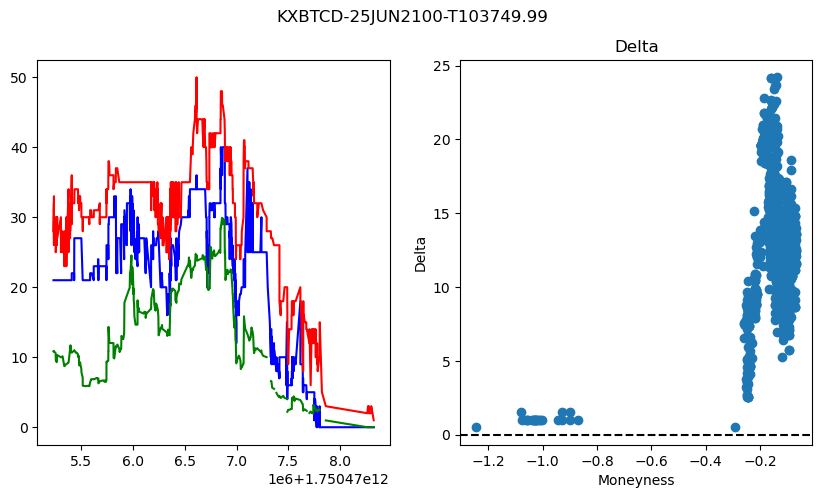

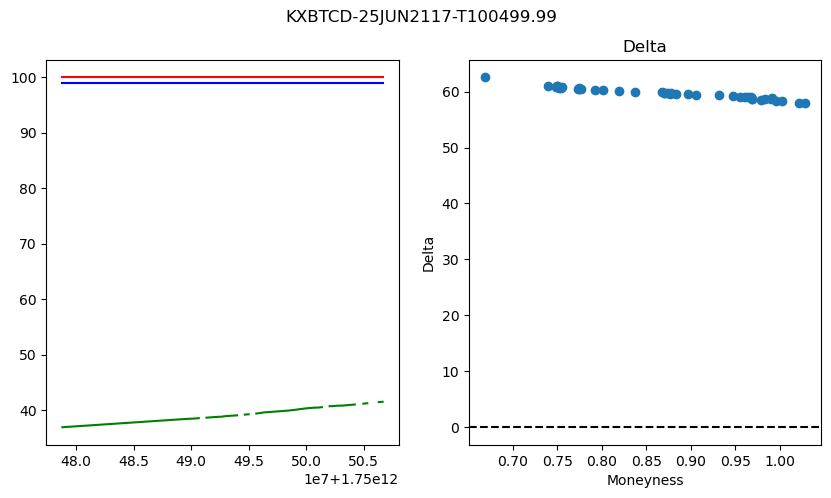

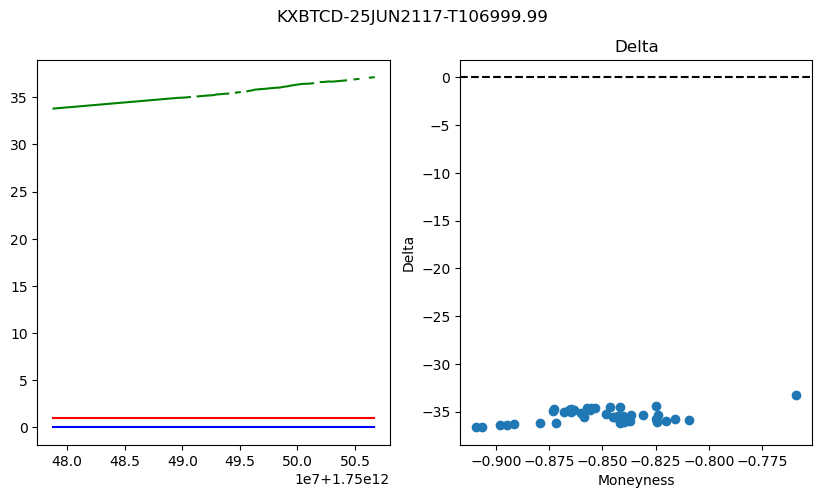

In [775]:
for ticker in quality_tickers.keys():
    prices = []
    monies = []

    for row in quality_tickers[ticker].iterrows():

        strike = get_strike(row[1]['ticker'])
        tte = row[1]['tte'] / 24 / 365 # in hours, convert to years
        brti_price = row[1]['brti_price']
        realized_vol = row[1]['realized_vol']
        vol_of_vol = row[1]['vol_of_vol']
        tte = row[1]['tte'] / 24 / 365

        moneyness = np.log(brti_price / strike) / np.sqrt(tte) 

        counter += 1
        price = binary_call_price(brti_price, strike, tte, realized_vol) * 100
        prices.append(price)
        monies.append(moneyness)

    timestamps = quality_tickers[ticker]['timestamp_ms']
    bids = quality_tickers[ticker]['best_bid']
    asks = quality_tickers[ticker]['best_ask']
    prices = np.array(prices)
    
    deltas = (bids + asks) / 2 - prices

    plt.figure(figsize=(10, 5))
    plt.suptitle(ticker)
    plt.subplot(1, 2, 1)
    plt.plot(timestamps, bids, c='blue')
    plt.plot(timestamps, asks, c='red')
    plt.plot(timestamps, prices, c='green')

    plt.subplot(1, 2, 2)
    plt.scatter(monies, deltas)
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Moneyness')
    plt.ylabel('Delta')
    plt.title('Delta')
    plt.subplot(1, 2, 2)
    plt.show()

    



# solving for iv of the kalshi market

In [591]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# Helper functions remain the same
def vectorized_binary_price(S, K, T, r, sigma):
    sigma = np.maximum(sigma, 1e-10) # Use a slightly smaller epsilon
    d2 = (np.log(S / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d2)

def vectorized_binary_vega(S, K, T, r, sigma):
    sigma = np.maximum(sigma, 1e-10)
    sqrt_T = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt_T)
    return -norm.pdf(d1 - sigma * sqrt_T) * d1 / sigma

# The main function with the crucial fix
def fast_implied_vol_binary(market_price, S, K, T, initial_guess=0.5, max_iter=20, tolerance=0.02):
    """
    Calculates implied volatility using a Newton-Raphson method with a
    user-provided initial guess for stability.
    """

    # make r zeros array same length as others
    r = np.zeros(S.shape)

    market_price, S, K, T, r = map(np.asarray, [market_price, S, K, T, r])
    
    # --- THIS IS THE FIX ---
    # Use the provided GARCH forecast as the starting point, not a fixed value.
    # Ensure it's an array of the correct shape.
    sigma = np.full(S.shape, initial_guess)

    for i in range(max_iter):
        price_error = vectorized_binary_price(S, K, T, r, sigma) - market_price
        vega_val = vectorized_binary_vega(S, K, T, r, sigma)
        
        # Dampen the update step to prevent overshooting.
        # This makes the solver more stable.
        update = 0.7 * (price_error / (vega_val + 1e-9))
        sigma = sigma - update

        if np.all(np.abs(update) < tolerance):
            break

    # Final cleanup
    sigma[market_price <= 0.01] = np.nan
    sigma[market_price >= 0.99] = np.nan
    sigma[(T <= 0)] = np.nan
    sigma[np.isnan(sigma) | np.isinf(sigma) | (sigma <= 0) | (sigma > 5.0)] = np.nan # Cap vol at 500%
    
    return sigma

In [776]:
quality_tickers.keys()


for ticker in quality_tickers.keys():

    bid_price = quality_tickers[ticker]['best_bid'] / 100
    ask_price = quality_tickers[ticker]['best_ask'] / 100 

    mid_price = (bid_price + ask_price) / 2
    
    S = quality_tickers[ticker]['brti_price']
    T = quality_tickers[ticker]['tte'] / 24 / 365

    quality_tickers[ticker]['bid_IV'] = fast_implied_vol_binary(bid_price, S, K, T)
    quality_tickers[ticker]['ask_IV'] = fast_implied_vol_binary(ask_price, S, K, T)
    quality_tickers[ticker]['mid_IV'] = fast_implied_vol_binary(mid_price, S, K, T)
    # plt.figure()
    # plt.title(ticker)
    # plt.plot(quality_tickers[ticker]['implied_vol'])
    # bids = quality_tickers[ticker]['best_bid']
    # asks = quality_tickers[ticker]['best_ask']
    # plt.twinx()
    # plt.plot(bids, c='green')
    # plt.plot(asks, c='red')
    # plt.show()

In [777]:
for ticker in quality_tickers.keys():
    quality_tickers[ticker]['log_moneyness'] = np.log(quality_tickers[ticker]['brti_price'] / get_strike(ticker)) / np.sqrt(quality_tickers[ticker]['tte'] / 24 / 365)

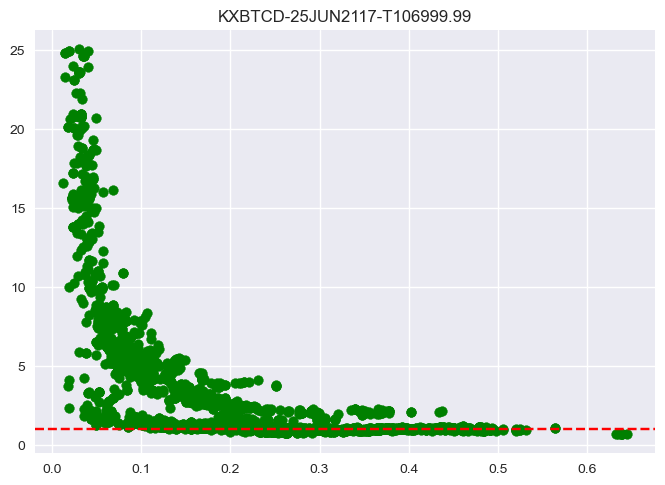

In [807]:
bid_IV_ratios = []
M1s = []
ask_IV_ratios = []
M2s = []

mid_IV_ratios = []
M3s = []

for ticker in quality_tickers.keys():

    for row in quality_tickers[ticker].iterrows():
        # filter for good quality data
        # spread must be less than 8

        if abs(row[1]['best_ask'] - row[1]['best_bid']) > 20:
            continue

        # tte in hours, 
        if row[1]['tte'] <= 0.01:
            continue

        # check for size of best bid and best ask
        if row[1]['best_bid_qty'] < 800 or row[1]['best_ask_qty'] < 800:
            continue


        if row[1]['realized_vol'] is None:
            continue

        if row[1]['mid_IV'] is None:
            continue
        
        mid_IV_ratios.append(row[1]['mid_IV']/row[1]['realized_vol'])
        M3s.append(row[1]['log_moneyness'])

        if row[1]['bid_IV'] is None:
            continue

        bid_IV_ratios.append(row[1]['bid_IV']/row[1]['realized_vol'])
        M1s.append(row[1]['log_moneyness'])

        if row[1]['ask_IV'] is None:    
            continue
    
        ask_IV_ratios.append(row[1]['ask_IV']/row[1]['realized_vol'])
        M2s.append(row[1]['log_moneyness'])

plt.figure()

# plt.scatter(M1s, bid_IV_ratios, c='blue'

# plt.scatter(M2s, ask_IV_ratios, c='red')
plt.title(ticker)
plt.scatter(M3s, mid_IV_ratios, c='green')
plt.axhline(y=1, color='red', linestyle='--')
plt.show()

In [808]:
data_df = pd.DataFrame({"moneyness" : M3s, "iv": mid_IV_ratios})
data_df = data_df.dropna()

filtered_data = data_df[(data_df['moneyness'] < 0.35)]
# filtered_data = data_df

[2.71741982]
Exponential MSE:  5.6608


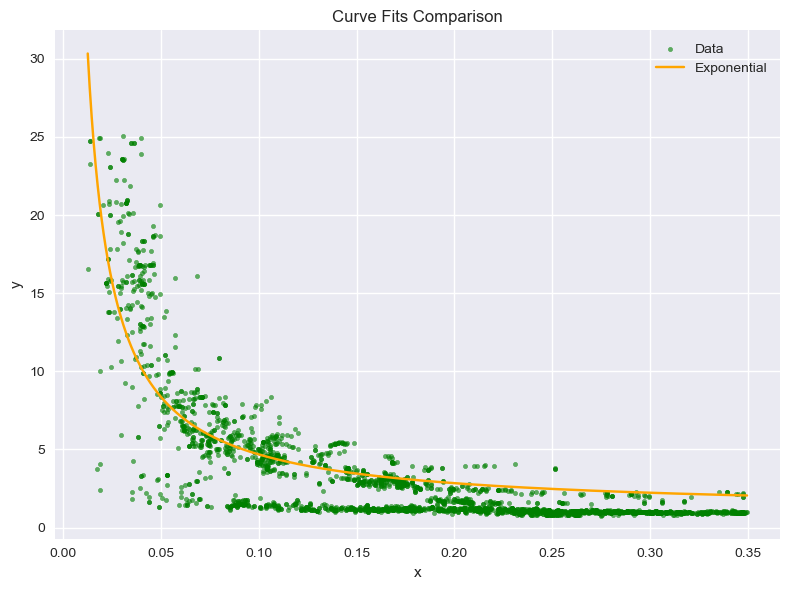

In [811]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

x_data = np.array(filtered_data['moneyness'])
y_data = np.array(filtered_data['iv'])


# --- Model 3: Exponential Decay ---
def exp_model(x, a):
    return 1 / (a * x) + 1


# --- Fit each model ---
popt_exp, _ = curve_fit(exp_model, x_data, y_data, maxfev=10000)

print(popt_exp)


# --- Predict using the fitted models ---
x_fit = np.linspace(min(x_data), max(x_data), 1000)
y_fit_exp = exp_model(x_fit, *popt_exp)

# --- Compute fit errors ---
mse_exp = mean_squared_error(y_data, exp_model(x_data, *popt_exp))


print(f"Exponential MSE:  {mse_exp:.4f}")

# --- Plot all fits ---
plt.figure(figsize=(8,6))
plt.scatter(x_data, y_data, color='green', s=10, label='Data', alpha=0.6)

plt.plot(x_fit, y_fit_exp, color='orange', label='Exponential')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Curve Fits Comparison')
plt.grid(True)
plt.tight_layout()
plt.show()


In [817]:
def model_iv_ratio(moneyness):
    return 1 / (np.e * moneyness) + 1

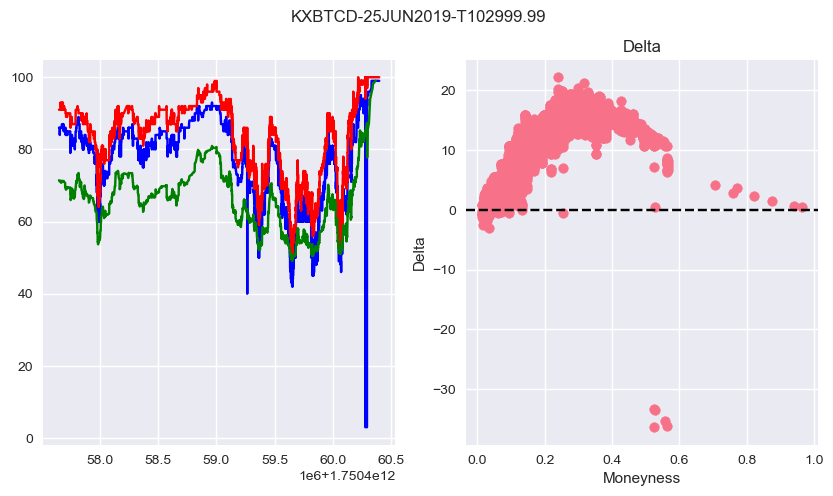

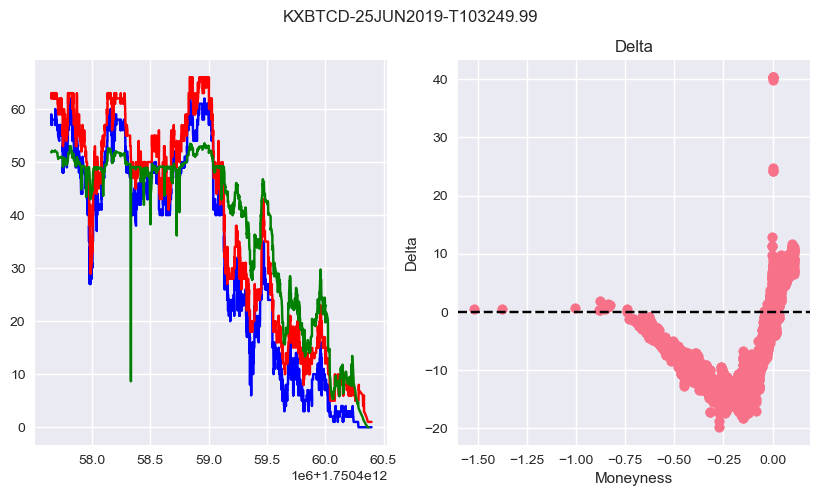

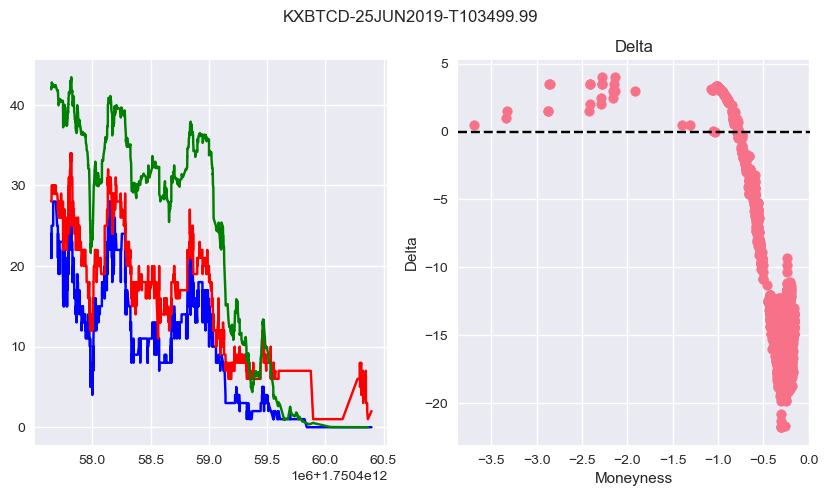

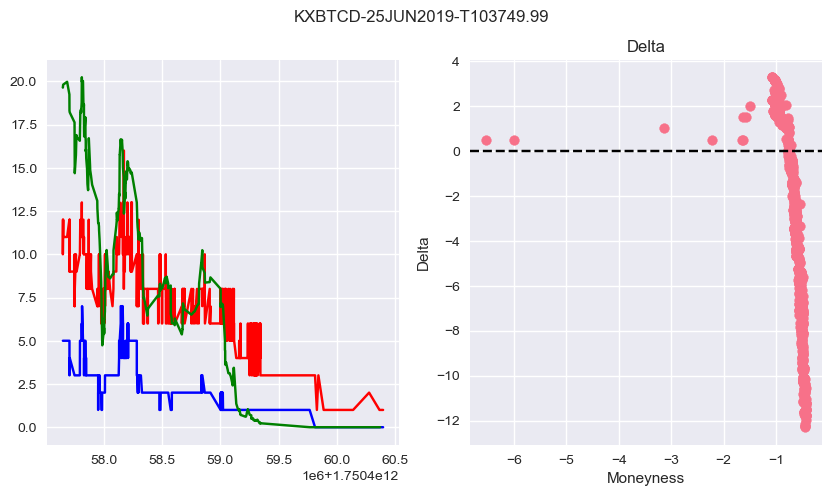

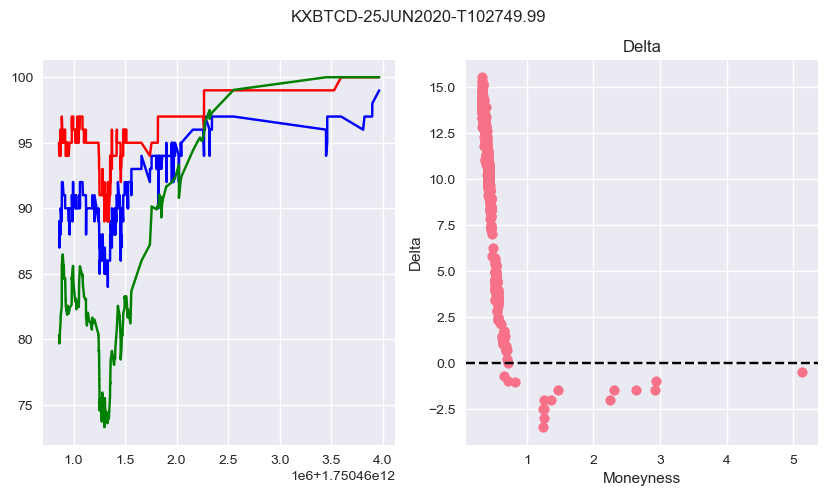

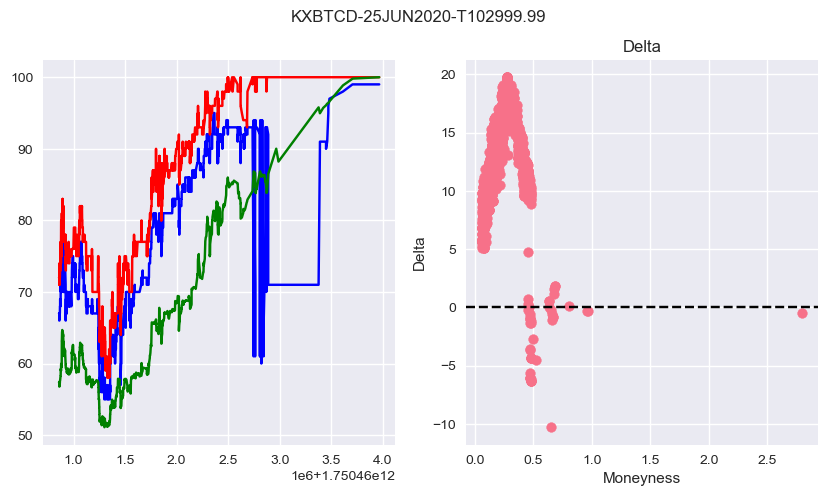

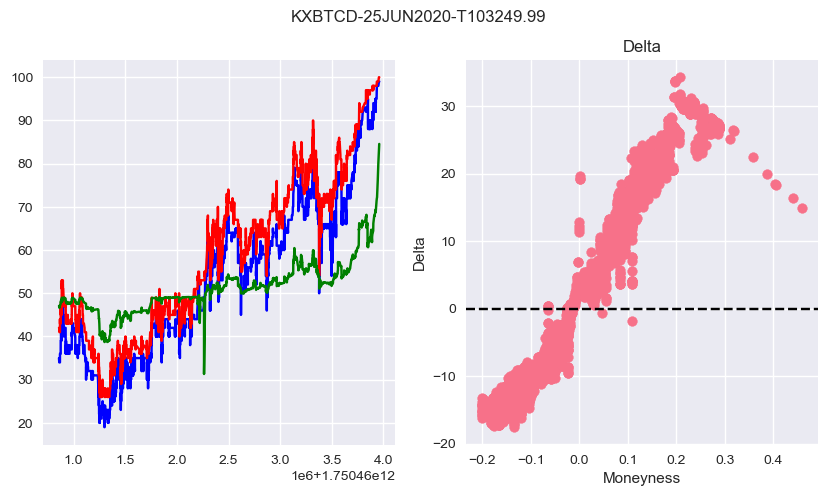

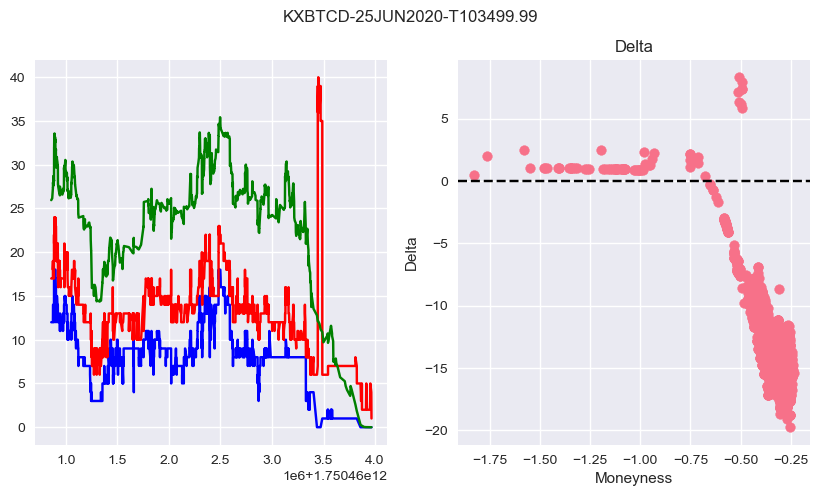

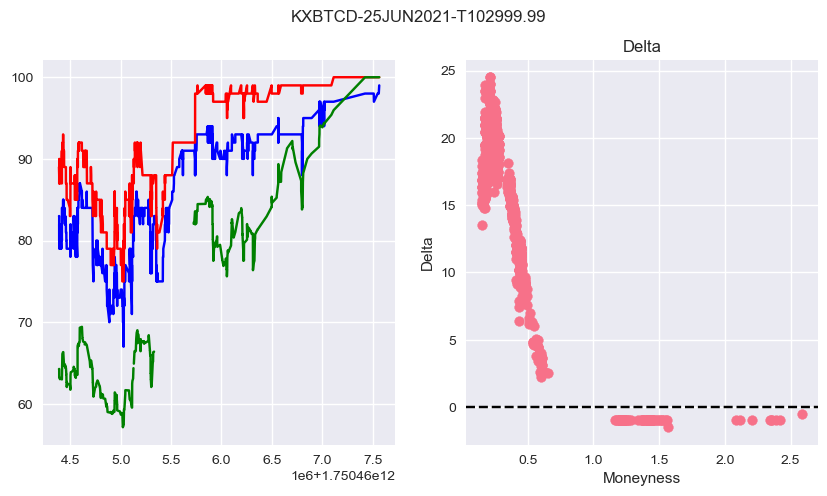

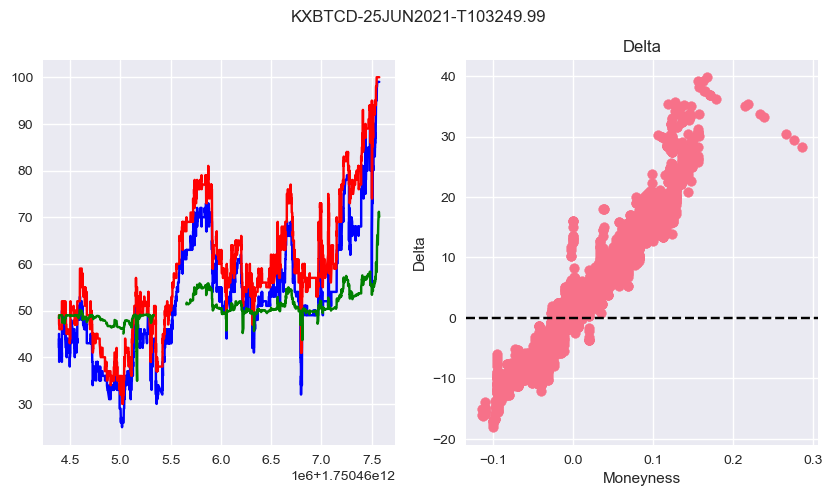

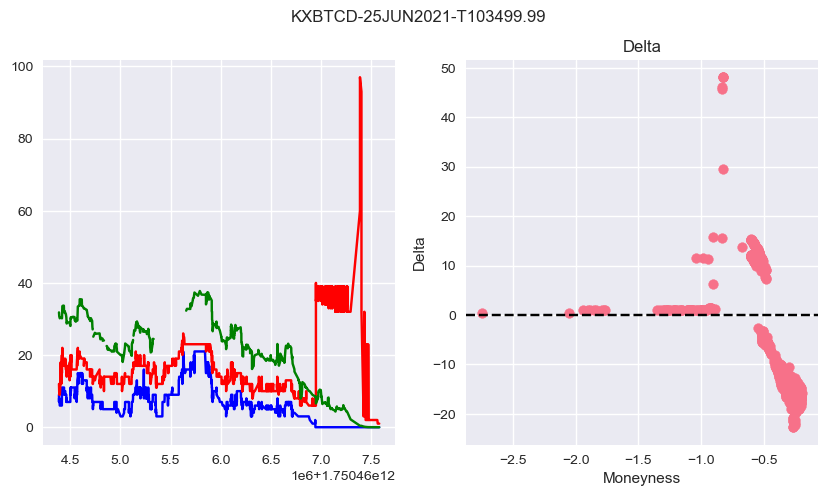

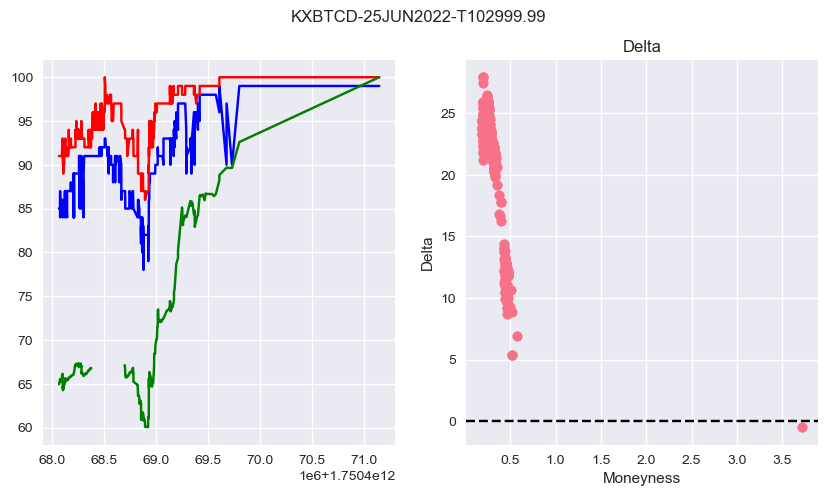

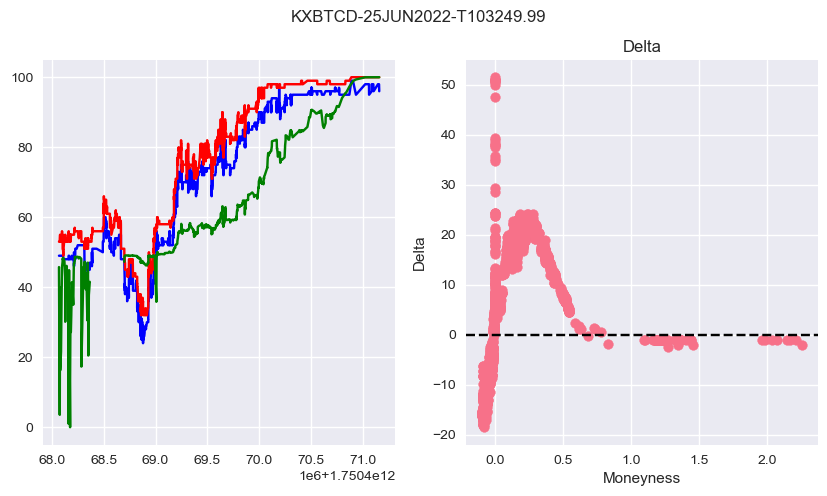

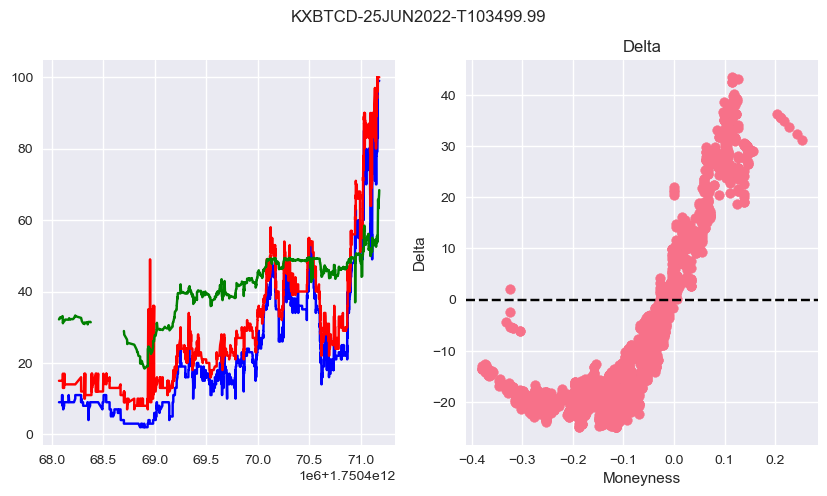

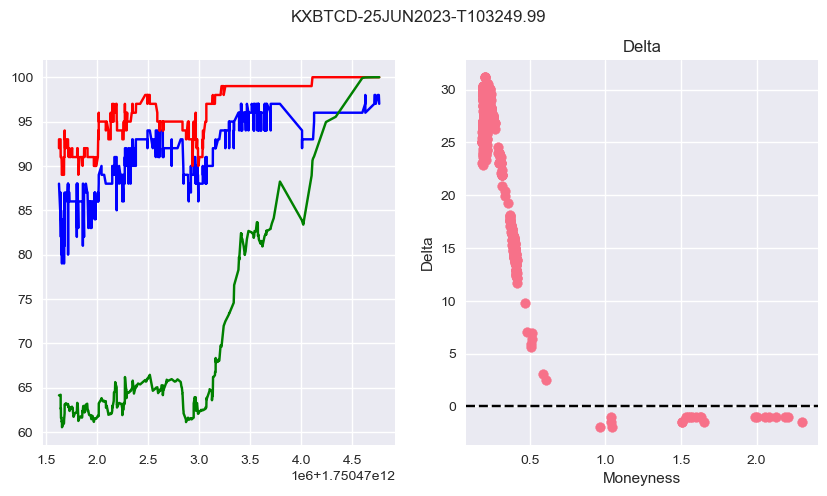

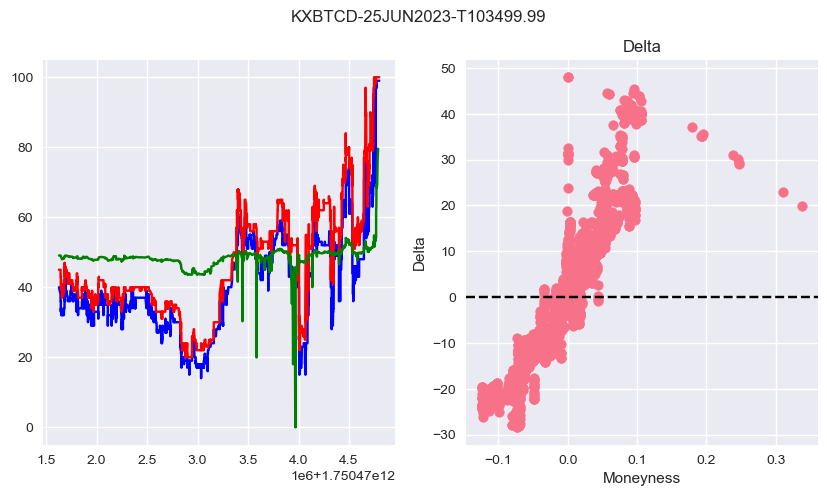

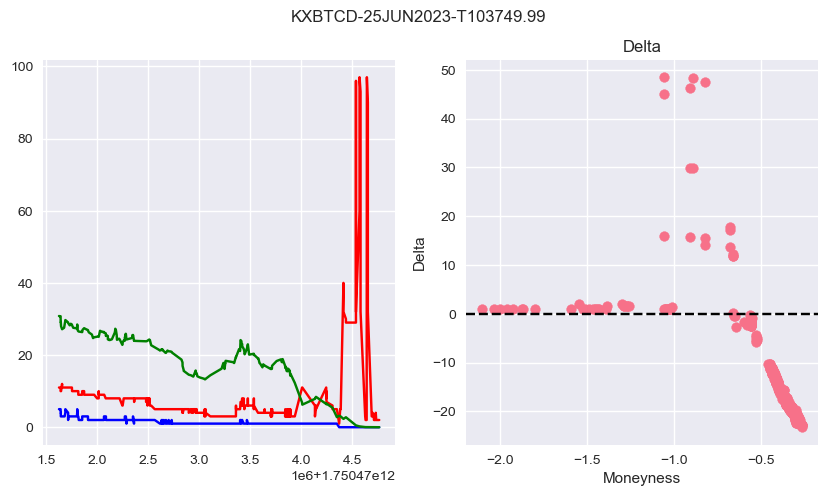

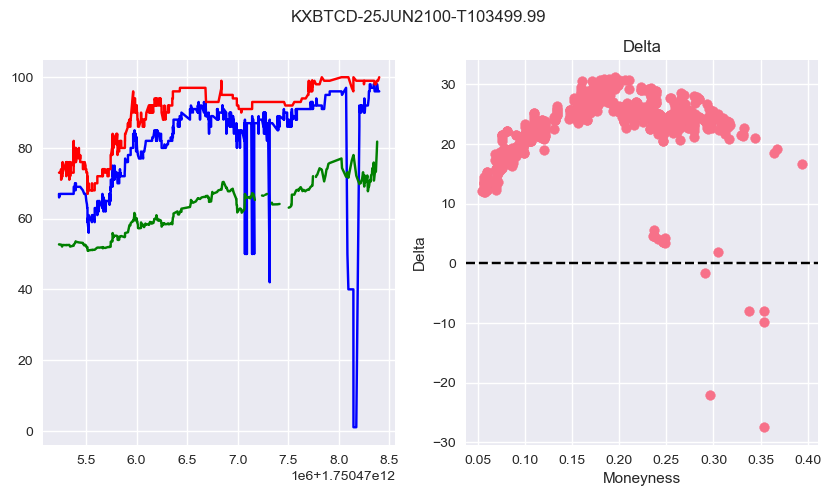

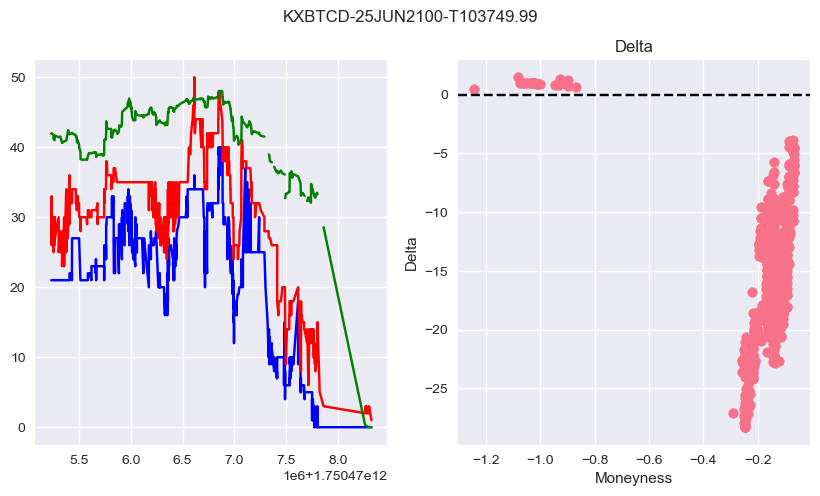

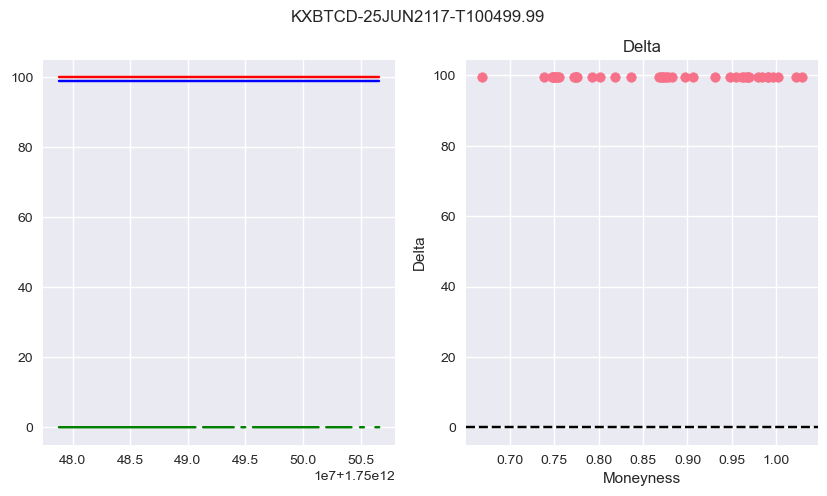

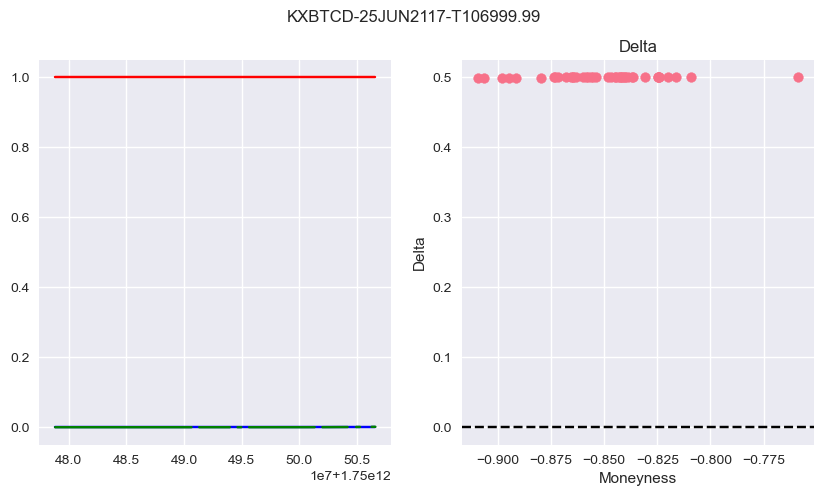

In [821]:
for ticker in quality_tickers.keys():
    prices = []
    monies = []

    for row in quality_tickers[ticker].iterrows():

        strike = get_strike(row[1]['ticker'])
        tte = row[1]['tte'] / 24 / 365 # in hours, convert to years
        brti_price = row[1]['brti_price']
        realized_vol = row[1]['realized_vol']
        vol_of_vol = row[1]['vol_of_vol']
        tte = row[1]['tte'] / 24 / 365

        moneyness = np.log(brti_price / strike) / np.sqrt(tte)

        IV_ratio = model_iv_ratio(abs(moneyness))
        realized_vol = IV_ratio * realized_vol

        price = binary_call_price(brti_price, strike, tte, realized_vol) * 100
        prices.append(price)
        monies.append(moneyness)

    timestamps = quality_tickers[ticker]['timestamp_ms']
    bids = quality_tickers[ticker]['best_bid']
    asks = quality_tickers[ticker]['best_ask']
    prices = np.array(prices)
    
    deltas = (bids + asks) / 2 - prices

    plt.figure(figsize=(10, 5))
    plt.suptitle(ticker)
    plt.subplot(1, 2, 1)
    plt.plot(timestamps, bids, c='blue')
    plt.plot(timestamps, asks, c='red')
    plt.plot(timestamps, prices, c='green')

    plt.subplot(1, 2, 2)
    plt.scatter(monies, deltas)
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Moneyness')
    plt.ylabel('Delta')
    plt.title('Delta')
    plt.subplot(1, 2, 2)
    plt.show()

    

In [538]:
vol_df = pd.DataFrame({'M': M, 'V': vol_ratio})

print(len(vol_df))
# filter our nan rows
vol_df = vol_df.dropna()
print(len(vol_df))

vol_df.head()

37989
17017


,M,V
0,0.505458,1.315419
1,0.504840,1.313813
2,0.504645,1.313304
3,0.461456,1.200922
4,0.461283,1.200472


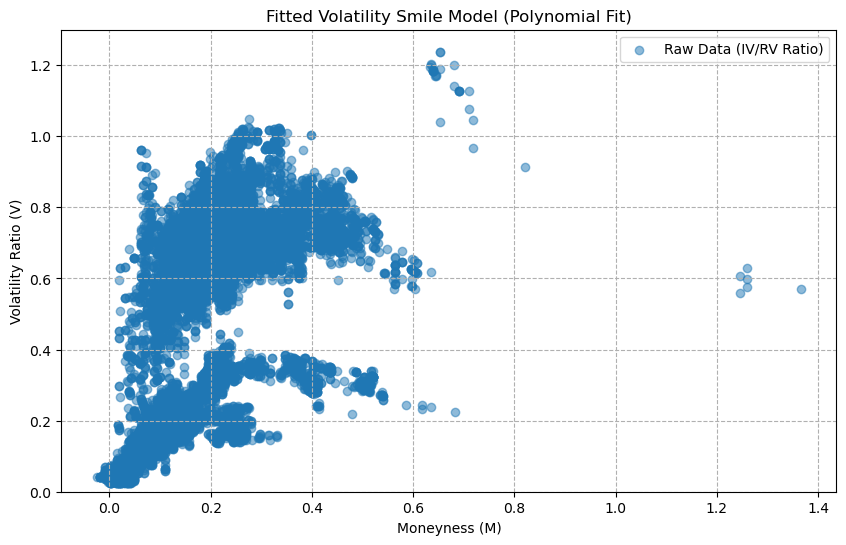

In [567]:
import numpy as np
import pandas as pd
from numpy.polynomial.polynomial import Polynomial
import matplotlib.pyplot as plt


M_clean = vol_df['M']
V_clean = vol_df['V']

V_clean = 1/ V_clean

# Plot the original data and the fitted curve
plt.figure(figsize=(10, 6))
plt.scatter(M_clean, V_clean, label='Raw Data (IV/RV Ratio)', alpha=0.5)
plt.title('Fitted Volatility Smile Model (Polynomial Fit)')
plt.xlabel('Moneyness (M)')
plt.ylabel('Volatility Ratio (V)')
plt.grid(True, linestyle='--')
plt.ylim(0, V_clean.max() * 1.05) # Use the clean data for ylim
plt.legend()
plt.show()